# Comparison of CNN and Transfomers using Brain Tumor Dection using MRI Images 

## Import All Required Libraries

In [1]:
# Basic utilities
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image
import cv2

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
                                     BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Transformers
from tensorflow.keras import layers
from tensorflow.keras.models import Model

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Set random seeds
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


2025-05-01 15:12:42.696575: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746112362.865672      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746112362.912023      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Prepare Data Loaders for Training and Validation

In [2]:
# Define paths
train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"

# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ImageDataGenerator with validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  # 20% for validation
)

# Training generator (80%)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Validation generator (20%)
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# View class indices
print("Class mapping:", train_generator.class_indices)


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## Dataset Exploration & Statistical Analysis Plan

### Count Number of Images per Class

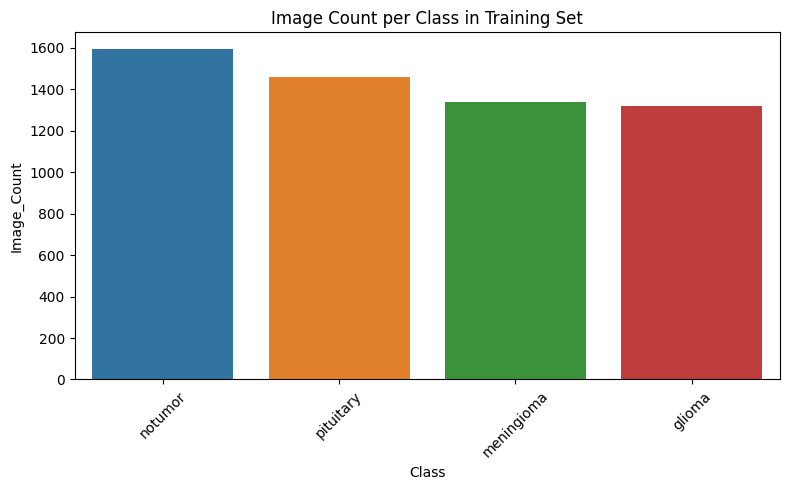

In [3]:
from collections import defaultdict

def count_images_per_class(folder_path):
    class_counts = defaultdict(int)
    for class_folder in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_folder)
        if os.path.isdir(class_path):
            class_counts[class_folder] = len(os.listdir(class_path))
    return class_counts

# Count images
train_counts = count_images_per_class(train_dir)

# Convert to DataFrame for plotting
train_df = pd.DataFrame(list(train_counts.items()), columns=['Class', 'Image_Count'])
train_df = train_df.sort_values(by='Image_Count', ascending=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=train_df, x='Class', y='Image_Count')
plt.title("Image Count per Class in Training Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Show Sample Images from Each Class

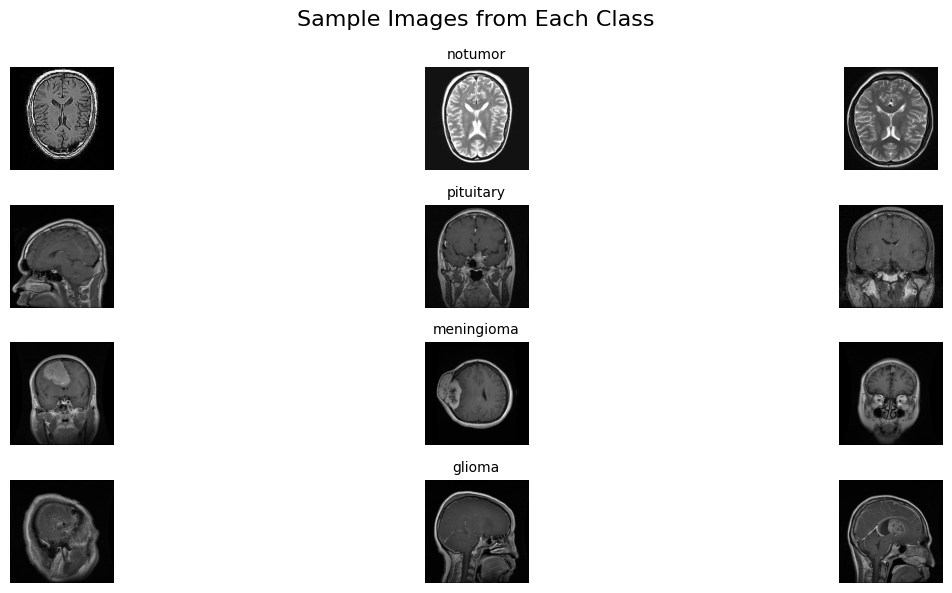

In [4]:
def show_sample_images(folder_path, classes, n_images=3):
    plt.figure(figsize=(15, 6))
    for i, cls in enumerate(classes):
        class_folder = os.path.join(folder_path, cls)
        image_files = os.listdir(class_folder)[:n_images]
        for j, img_file in enumerate(image_files):
            img_path = os.path.join(class_folder, img_file)
            img = Image.open(img_path)
            plt.subplot(len(classes), n_images, i*n_images + j + 1)
            plt.imshow(img, cmap='gray')
            plt.axis('off')
            if j == 1:
                plt.title(cls, fontsize=10)
    plt.suptitle("Sample Images from Each Class", fontsize=16)
    plt.tight_layout()
    plt.show()

# Show 3 images from each class
show_sample_images(train_dir, train_df['Class'].tolist(), n_images=3)


### Analyze Image Dimensions

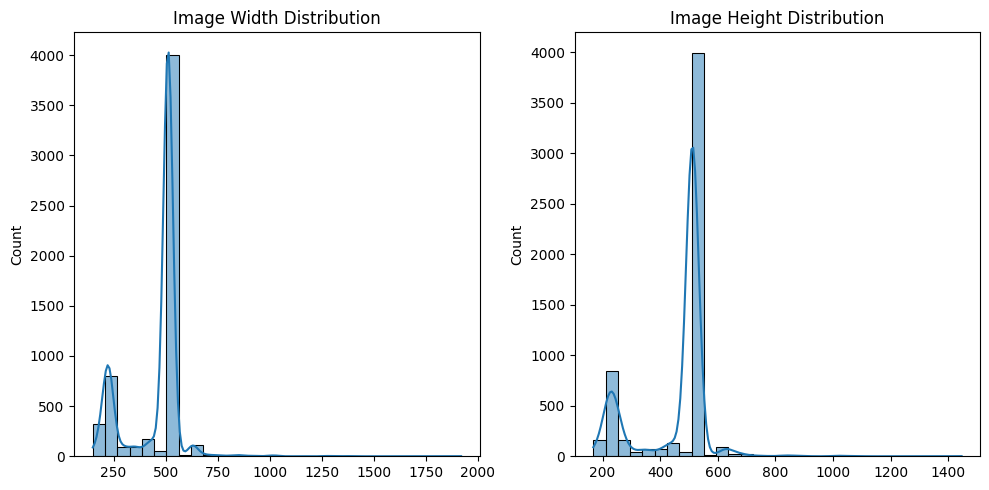

In [5]:
def get_image_shapes(folder_path):
    widths, heights = [], []
    for class_folder in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_folder)
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
            except:
                continue
    return widths, heights

widths, heights = get_image_shapes(train_dir)

# Plot dimensions
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
sns.histplot(widths, bins=30, kde=True)
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
sns.histplot(heights, bins=30, kde=True)
plt.title("Image Height Distribution")

plt.tight_layout()
plt.show()


### Pixel Intensity Stats

In [6]:
def compute_pixel_stats(folder_path, n_images=500):
    means = []
    stds = []
    count = 0
    for class_folder in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_folder)
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                means.append(np.mean(img))
                stds.append(np.std(img))
                count += 1
            if count >= n_images:
                break
    return np.mean(means), np.mean(stds)

mean_pixel, std_pixel = compute_pixel_stats(train_dir)
print(f"Average pixel intensity mean: {mean_pixel:.2f}, std: {std_pixel:.2f}")


Average pixel intensity mean: 49.46, std: 41.67


## Check if the dataset is Balance

In [7]:
# Path to full training dataset
train_dir_path = "/kaggle/input/brain-tumor-mri-dataset/Training"

# Count number of images per class
class_counts = {
    class_name: len(os.listdir(os.path.join(train_dir_path, class_name)))
    for class_name in os.listdir(train_dir_path)
    if os.path.isdir(os.path.join(train_dir_path, class_name))
}

# Convert to DataFrame
class_df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Image_Count'])

In [8]:
import plotly.express as px

# Create a treemap
fig = px.treemap(
    class_df,
    path=['Class'],
    values='Image_Count',
    color='Image_Count',
    color_continuous_scale='Viridis',
    title='Class Distribution Treemap - Brain Tumor Training Set'
)

fig.update_layout(
    margin=dict(t=50, l=25, r=25, b=25),
    font=dict(size=14)
)

fig.show()

In [9]:
import plotly.express as px

# 1. Count images per class
class_counts = count_images_per_class(train_dir)
class_df = pd.DataFrame(class_counts.items(), columns=["Class", "Image_Count"])

# 2. Compute mean and standard deviation
mean_count = class_df["Image_Count"].mean()
std_count = class_df["Image_Count"].std()
lower_thresh = mean_count - std_count

# 3. Determine balance status based only on lower threshold
class_df["Balanced"] = class_df["Image_Count"].apply(
    lambda x: "No" if x < lower_thresh else "Yes"
)

# 4. Print summary
print(f"Mean image count: {mean_count:.2f}")
print(f"Standard deviation: {std_count:.2f}")
print(f"Lower threshold: {lower_thresh:.0f}")
display(class_df)

# 5. Plot treemap
fig = px.treemap(
    class_df,
    path=['Class'],
    values='Image_Count',
    color='Balanced',
    color_discrete_map={'Yes': 'lightgreen', 'No': 'tomato'},
    title='Brain Tumor Dataset Class Distribution (Based on Lower Threshold)'
)
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()



Mean image count: 1428.00
Standard deviation: 126.62
Lower threshold: 1301


,Class,Image_Count,Balanced
0,pituitary,1457,Yes
1,notumor,1595,Yes
2,meningioma,1339,Yes
3,glioma,1321,Yes


In [10]:
import plotly.express as px

# Create a "Balanced" column just for consistency
class_df["Balanced"] = "Yes"

# Plot treemap (all green since it's balanced)
fig = px.treemap(
    class_df,
    path=['Class'],
    values='Image_Count',
    color='Balanced',
    color_discrete_map={'Yes': 'green'},
    title='Class Distribution Treemap - Brain Tumor Training Set (Balanced)'
)

fig.update_layout(
    margin=dict(t=50, l=25, r=25, b=25),
    font=dict(size=14)
)

fig.show()

### Histogram of Image Counts per Class (Training Set)

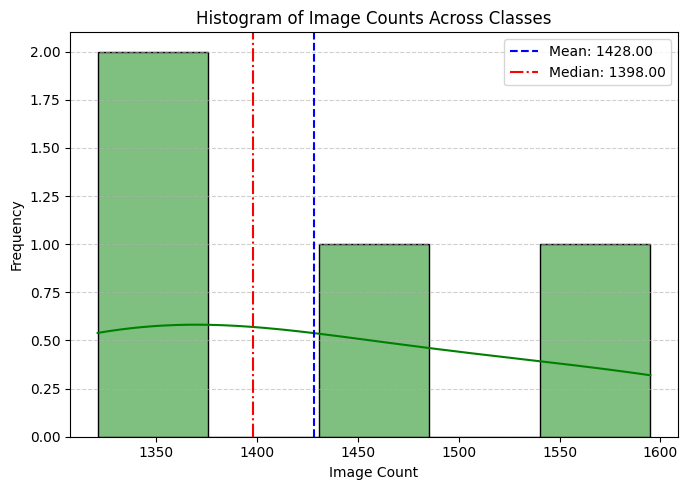

Mean: 1428.00
Median: 1398.00
Standard Deviation: 126.62


In [11]:
# Extract image counts
counts = class_df["Image_Count"]

# Calculate basic stats
mean_val = counts.mean()
median_val = counts.median()
std_val = counts.std()

# Plot histogram
plt.figure(figsize=(7, 5))
sns.histplot(counts, bins=5, kde=True, color='green')

# Add vertical lines for mean and median
plt.axvline(mean_val, color='blue', linestyle='--', label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color='red', linestyle='-.', label=f"Median: {median_val:.2f}")

# Formatting
plt.title("Histogram of Image Counts Across Classes")
plt.xlabel("Image Count")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Print stats
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Standard Deviation: {std_val:.2f}")


## Image Preprocessing

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Initialize ImageDataGenerator WITHOUT 'color_mode'
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=10,
    validation_split=0.2
)

# Training generator (80%)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',  # Passed here, not in the generator
    subset='training',
    shuffle=True,
    seed=42
)

# Validation generator (20%)
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    subset='validation',
    shuffle=False,
    seed=42
)

# Sample batch shapes
x_batch, y_batch = next(train_generator)
print("X shape:", x_batch.shape)  # Expected: (32, 224, 224, 1)
print("Y shape:", y_batch.shape)  


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
X shape: (32, 224, 224, 1)
Y shape: (32, 4)


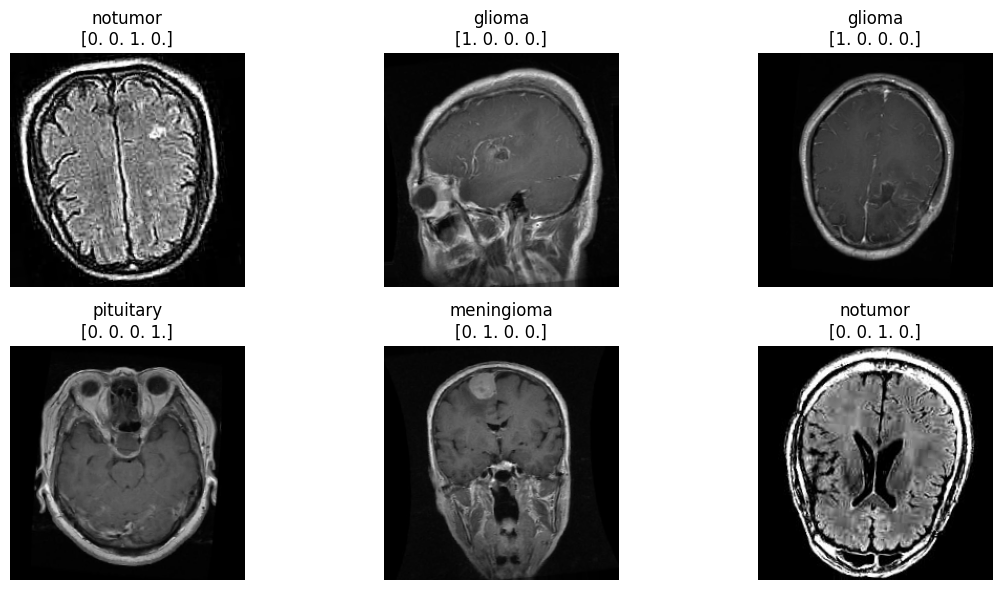

In [13]:
# Get one batch of images and labels
x_batch, y_batch = next(train_generator)

# Get class labels
class_labels = list(train_generator.class_indices.keys())
inv_map = {v: k for k, v in train_generator.class_indices.items()}

# Show 6 images with their one-hot label + class name
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_batch[i].squeeze(), cmap='gray')  # squeeze removes extra dim
    class_idx = y_batch[i].argmax()  # Convert one-hot to index
    class_name = inv_map[class_idx]
    one_hot = y_batch[i]
    plt.title(f"{class_name}\n{one_hot}")
    plt.axis('off')
plt.tight_layout()
plt.show()


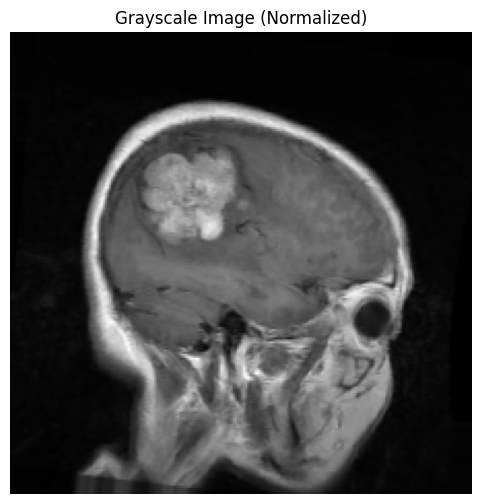

Sample of Normalized Pixel Array (shape: (224, 224)):
[[0.372 0.333 0.319 0.321 0.315 0.31  0.316 0.324 0.331 0.354]
 [0.337 0.336 0.331 0.333 0.332 0.332 0.332 0.337 0.345 0.368]
 [0.326 0.33  0.331 0.336 0.344 0.347 0.346 0.349 0.36  0.369]
 [0.326 0.321 0.321 0.326 0.335 0.346 0.352 0.353 0.363 0.368]
 [0.331 0.322 0.319 0.324 0.322 0.339 0.354 0.358 0.363 0.365]
 [0.332 0.324 0.32  0.323 0.322 0.339 0.354 0.36  0.364 0.368]
 [0.335 0.324 0.321 0.322 0.324 0.341 0.354 0.358 0.358 0.357]
 [0.335 0.323 0.322 0.321 0.326 0.344 0.355 0.356 0.353 0.352]
 [0.332 0.326 0.323 0.329 0.337 0.342 0.343 0.34  0.338 0.338]
 [0.331 0.34  0.342 0.341 0.338 0.338 0.337 0.331 0.33  0.328]]


In [14]:


# Get one batch
x_batch, y_batch = next(train_generator)

# Select one image from the batch (first one)
image = x_batch[0].squeeze()  # shape: (224, 224)

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title("Grayscale Image (Normalized)")
plt.axis('off')
plt.show()

# Show array values (trimmed)
print("Sample of Normalized Pixel Array (shape: {}):".format(image.shape))
print(np.round(image[100:110, 100:110], 3))  # just a 10x10 region for clarity


### Heatmap

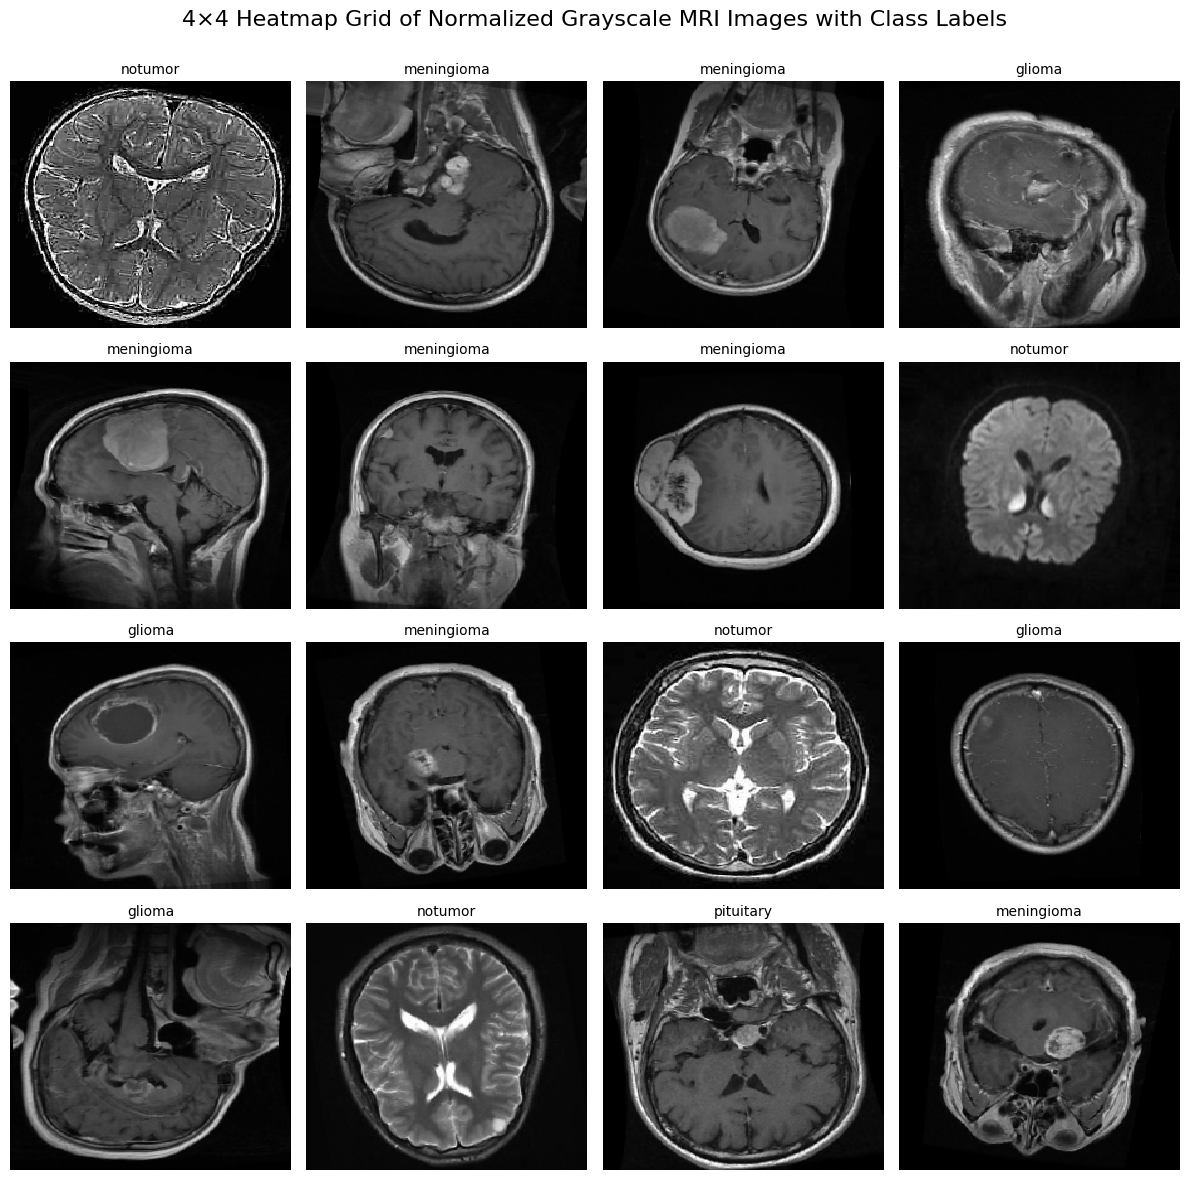

In [15]:
# Get one batch
x_batch, y_batch = next(train_generator)

# Reverse class index mapping
class_indices = train_generator.class_indices  # e.g., {'glioma': 0, ...}
inv_class_indices = {v: k for k, v in class_indices.items()}

# Plot 4×4 grid
plt.figure(figsize=(12, 12))
for i in range(16):
    image = x_batch[i].squeeze()
    class_idx = y_batch[i].argmax()
    class_name = inv_class_indices[class_idx]

    plt.subplot(4, 4, i + 1)
    sns.heatmap(image, cmap='gray', cbar=False, xticklabels=False, yticklabels=False)
    plt.title(f"{class_name}", fontsize=10)
    plt.axis('off')

plt.suptitle("4×4 Heatmap Grid of Normalized Grayscale MRI Images with Class Labels", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

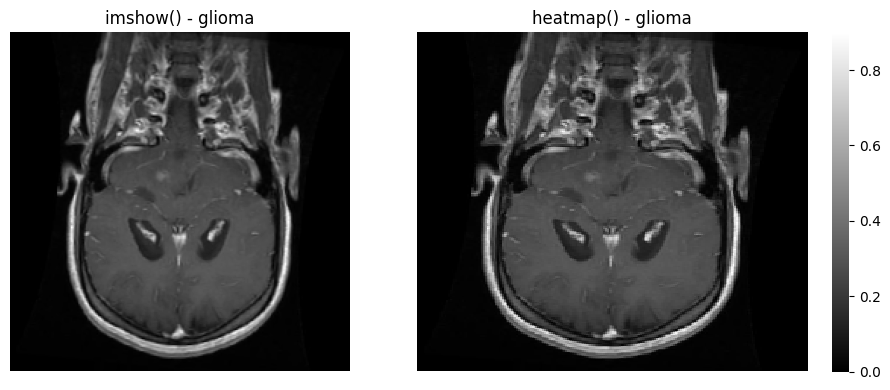

In [16]:
# Get one batch from the generator
x_batch, y_batch = next(train_generator)
image = x_batch[0].squeeze()  # shape: (224, 224)
label_idx = y_batch[0].argmax()
label_name = list(train_generator.class_indices.keys())[label_idx]

# Plot side-by-side
plt.figure(figsize=(10, 4))

# Using imshow
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title(f"imshow() - {label_name}")
plt.axis('off')

# Using heatmap
plt.subplot(1, 2, 2)
sns.heatmap(image, cmap='gray', cbar=True, xticklabels=False, yticklabels=False)
plt.title(f"heatmap() - {label_name}")
plt.axis('off')

plt.tight_layout()
plt.show()

### Test Generator Data setup

In [17]:
# Test directory
test_dir = "/kaggle/input/brain-tumor-mri-dataset/Testing"

# Create a test ImageDataGenerator (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Test generator (full batch size to evaluate all at once if needed)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,           # (224, 224)
    batch_size=BATCH_SIZE,
    class_mode='categorical',       # one-hot labels
    color_mode='grayscale',         # same as training
    shuffle=False                   # important for evaluation and prediction alignment
)

Found 1311 images belonging to 4 classes.


## CNN Models

### VGG16

### Build VGG16-Based Model

In [18]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Lambda
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

In [19]:
def build_vgg16_model():
    input_tensor = Input(shape=(224, 224, 1))
    rgb_tensor = Lambda(lambda x: tf.image.grayscale_to_rgb(x))(input_tensor)

    base_model = VGG16(weights='imagenet', include_top=False, input_tensor=rgb_tensor)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

model = build_vgg16_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

I0000 00:00:1746112406.438569      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


### Callbacks and Train the Model

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("vgg16_brain_tumor.keras", save_best_only=True)



history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/25


I0000 00:00:1746112415.554980     129 service.cc:148] XLA service 0x78b1c800e060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746112415.555734     129 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
W0000 00:00:1746112415.670197     129 assert_op.cc:38] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1746112415.671537     129 assert_op.cc:38] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert
I0000 00:00:1746112415.890217     129 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/143 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.3125 - loss: 1.5013 

I0000 00:00:1746112425.116438     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


123/143 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.3576 - loss: 1.3669

W0000 00:00:1746112447.071782     128 assert_op.cc:38] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1746112447.071963     128 assert_op.cc:38] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert


143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.3700 - loss: 1.3571

W0000 00:00:1746112456.897304     128 assert_op.cc:38] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1746112456.898750     128 assert_op.cc:38] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert
W0000 00:00:1746112464.092438     129 assert_op.cc:38] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1746112464.092555     129 assert_op.cc:38] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert


143/143 ━━━━━━━━━━━━━━━━━━━━ 57s 312ms/step - accuracy: 0.3706 - loss: 1.3567 - val_accuracy: 0.5741 - val_loss: 1.2317
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 223ms/step - accuracy: 0.6115 - loss: 1.1332 - val_accuracy: 0.6529 - val_loss: 1.1234
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 227ms/step - accuracy: 0.7301 - loss: 0.9831 - val_accuracy: 0.6564 - val_loss: 1.0454
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 226ms/step - accuracy: 0.7577 - loss: 0.8638 - val_accuracy: 0.6880 - val_loss: 0.9876
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 225ms/step - accuracy: 0.7848 - loss: 0.7786 - val_accuracy: 0.6705 - val_loss: 0.9620
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 221ms/step - accuracy: 0.8017 - loss: 0.7149 - val_accuracy: 0.6994 - val_loss: 0.9320
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 224ms/step - accuracy: 0.8327 - loss: 0.6472 - val_accuracy: 0.7029 - val_loss: 0.8927
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 222ms/step - accuracy: 0.8260 - loss: 0.6160 - val

### Test Loss and Accuracy

In [21]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7026 - loss: 0.8006

W0000 00:00:1746113260.720759     126 assert_op.cc:38] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1746113260.720936     126 assert_op.cc:38] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert


41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 338ms/step - accuracy: 0.7069 - loss: 0.7921
Test Accuracy: 0.7918
Test Loss: 0.6222


### Train Test Val Loss Plot

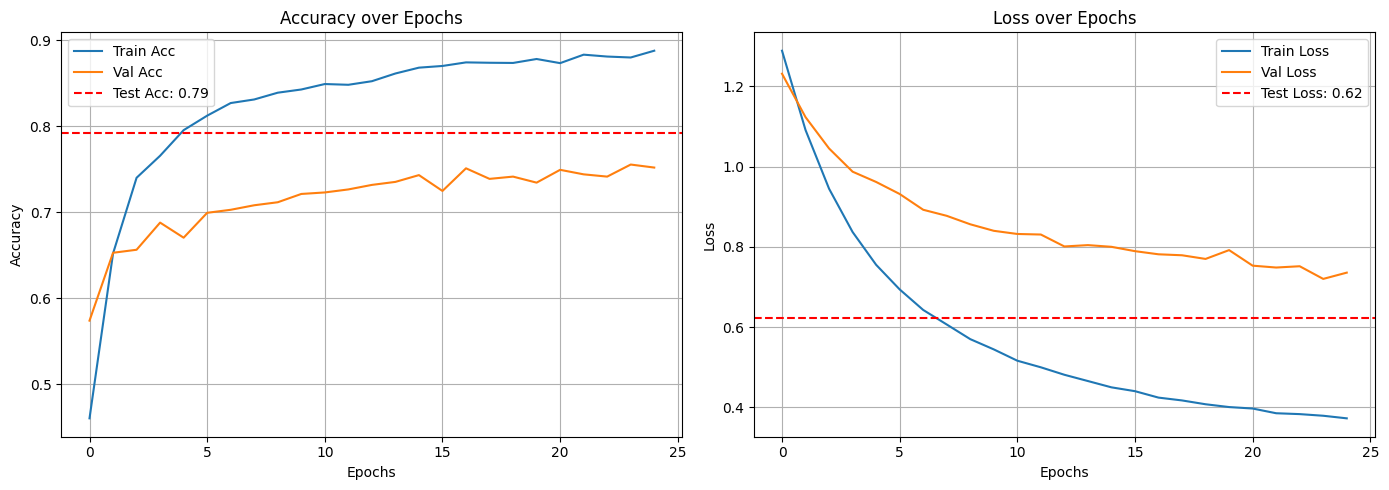

In [22]:
def plot_all_curves(history, test_acc, test_loss):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_all_curves(history, test_acc, test_loss)

### ROC - AUC Curve

40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

W0000 00:00:1746113271.900545     128 assert_op.cc:38] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1746113271.901698     128 assert_op.cc:38] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert


41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step


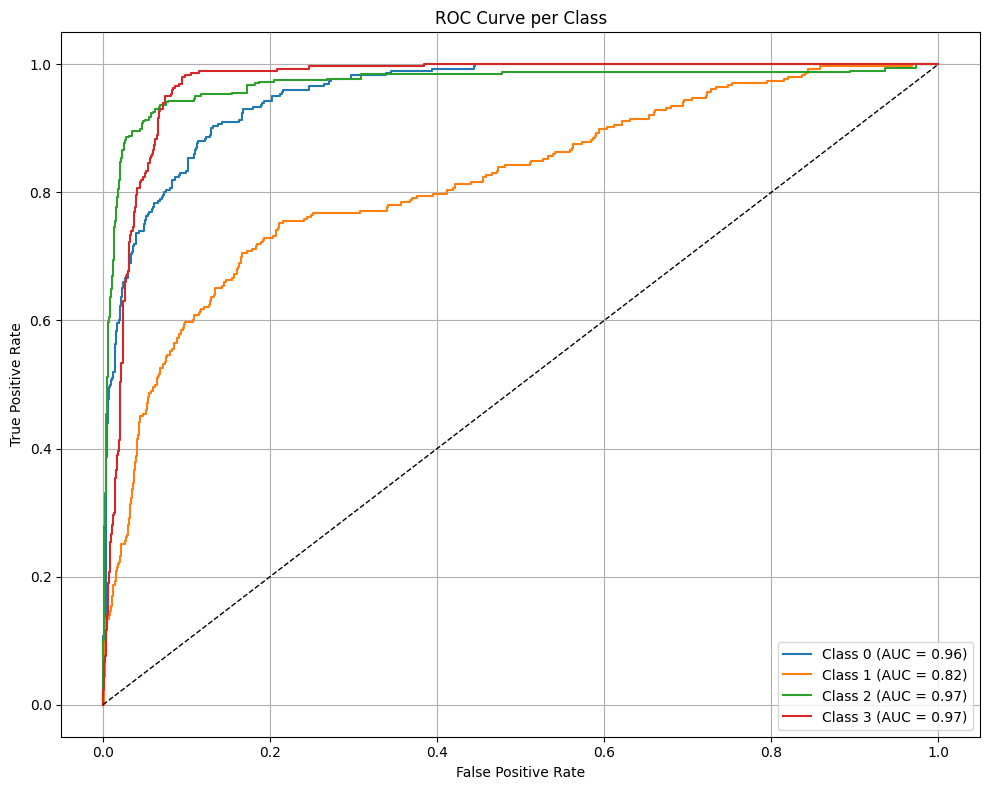

In [23]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Predictions
y_pred = model.predict(test_generator)
y_true = test_generator.classes
n_classes = y_pred.shape[1]

# One-hot encode the true labels
y_true_onehot = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

### Confusion Matrix

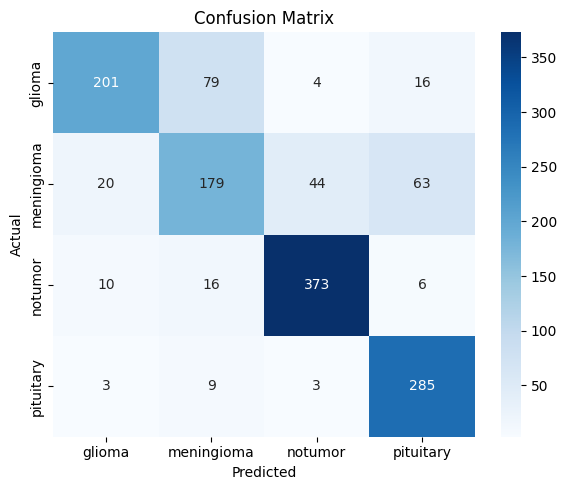

,precision,recall,f1-score,support
glioma,0.859,0.670,0.753,300.000
meningioma,0.633,0.585,0.608,306.000
notumor,0.880,0.921,0.900,405.000
pituitary,0.770,0.950,0.851,300.000
accuracy,0.792,0.792,0.792,0.792
macro avg,0.785,0.781,0.778,1311.000
weighted avg,0.792,0.792,0.787,1311.000


In [24]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd

# Get predicted class indices
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class)
df_cm = pd.DataFrame(cm, index=class_labels, columns=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Classification report (precision, recall, F1)
report = classification_report(y_true_class, y_pred_class, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Round values and print neatly
report_df = report_df.round(3)
display(report_df)

In [25]:
try:
    results_df
except NameError:
    results_df = pd.DataFrame(columns=["Model", "Test Accuracy", "Test Loss", "Precision", "Recall", "F1-Score", "AUC"])

# Compute macro average metrics
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

macro_precision = precision_score(y_true_class, y_pred_class, average='macro')
macro_recall = recall_score(y_true_class, y_pred_class, average='macro')
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
macro_auc = roc_auc_score(label_binarize(y_true_class, classes=np.arange(n_classes)), y_pred, average='macro', multi_class='ovr')

# Append VGG16 results
results_df.loc[len(results_df)] = [
    "VGG16", 
    test_acc, 
    test_loss, 
    round(macro_precision, 4), 
    round(macro_recall, 4), 
    round(macro_f1, 4), 
    round(macro_auc, 4)
]

# Display results so far
display(results_df)

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282


## ResNet50

### Build VGG16-Based Model

In [26]:
def build_resnet50_model():
    input_tensor = Input(shape=(224, 224, 1))
    rgb_tensor = Lambda(lambda x: tf.image.grayscale_to_rgb(x))(input_tensor)

    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=rgb_tensor)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

# Compile the model
model = build_resnet50_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


### Callbacks and Train the Model

In [27]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("resnet50_brain_tumor.keras", save_best_only=True)

history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25


W0000 00:00:1746113289.583962     127 assert_op.cc:38] Ignoring Assert operator functional_1_1/lambda_1_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1746113289.585354     127 assert_op.cc:38] Ignoring Assert operator functional_1_1/lambda_1_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert


  3/143 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - accuracy: 0.3299 - loss: 1.6319

W0000 00:00:1746113295.065520     128 assert_op.cc:38] Ignoring Assert operator functional_1_1/lambda_1_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1746113295.065653     128 assert_op.cc:38] Ignoring Assert operator functional_1_1/lambda_1_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert


143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.3030 - loss: 1.5110

W0000 00:00:1746113325.060635     126 assert_op.cc:38] Ignoring Assert operator functional_1_1/lambda_1_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1746113325.061881     126 assert_op.cc:38] Ignoring Assert operator functional_1_1/lambda_1_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert
W0000 00:00:1746113332.553018     129 assert_op.cc:38] Ignoring Assert operator functional_1_1/lambda_1_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1746113332.553223     129 assert_op.cc:38] Ignoring Assert operator functional_1_1/lambda_1_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert


143/143 ━━━━━━━━━━━━━━━━━━━━ 58s 297ms/step - accuracy: 0.3034 - loss: 1.5101 - val_accuracy: 0.5162 - val_loss: 1.2538
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 207ms/step - accuracy: 0.4335 - loss: 1.1851 - val_accuracy: 0.5968 - val_loss: 1.1939
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 212ms/step - accuracy: 0.5113 - loss: 1.1083 - val_accuracy: 0.6161 - val_loss: 1.1610
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 206ms/step - accuracy: 0.5646 - loss: 1.0531 - val_accuracy: 0.6231 - val_loss: 1.1361
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 210ms/step - accuracy: 0.5939 - loss: 1.0235 - val_accuracy: 0.6039 - val_loss: 1.1168
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 213ms/step - accuracy: 0.6075 - loss: 1.0056 - val_accuracy: 0.6433 - val_loss: 1.0959
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 210ms/step - accuracy: 0.6204 - loss: 0.9657 - val_accuracy: 0.6564 - val_loss: 1.0637
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 209ms/step - accuracy: 0.6303 - loss: 0.9648 - val

### Test Loss and Accuracy

In [28]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.5784 - loss: 1.1267
Test Accuracy: 0.6491
Test Loss: 0.9688


### Train Test Val Accuracy And Loss Plot

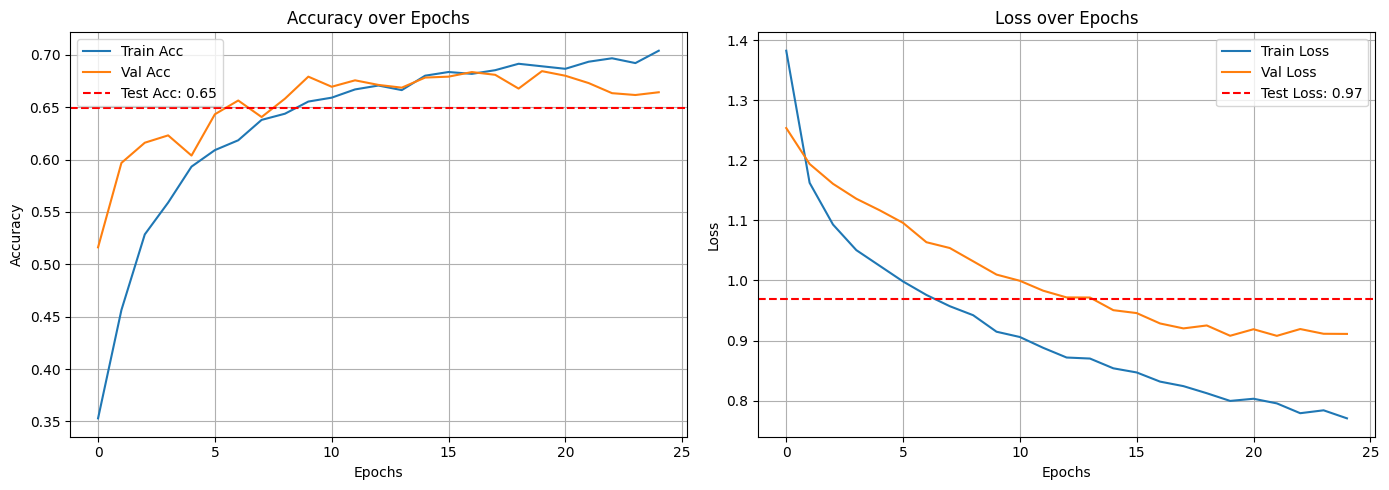

In [29]:
def plot_all_curves(history, test_acc, test_loss):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_all_curves(history, test_acc, test_loss)

### AUC-ROC Curve

41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step


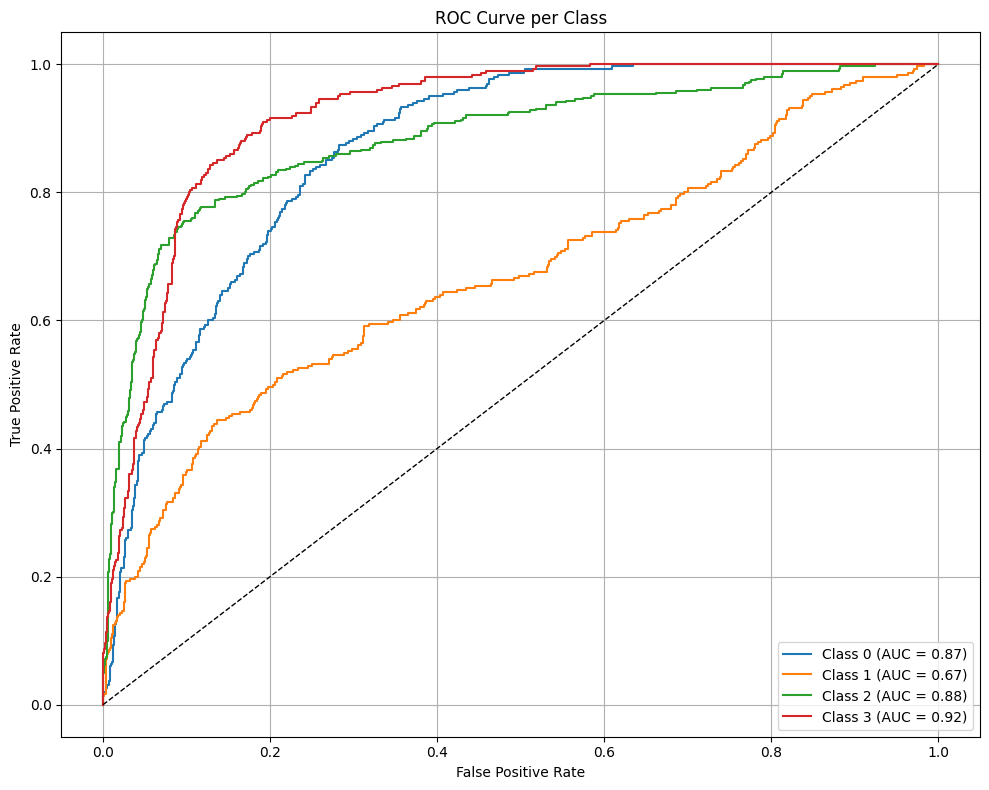

In [30]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Predictions
y_pred = model.predict(test_generator)
y_true = test_generator.classes
n_classes = y_pred.shape[1]

# One-hot encode the true labels
y_true_onehot = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

### Confusiuon Matrix

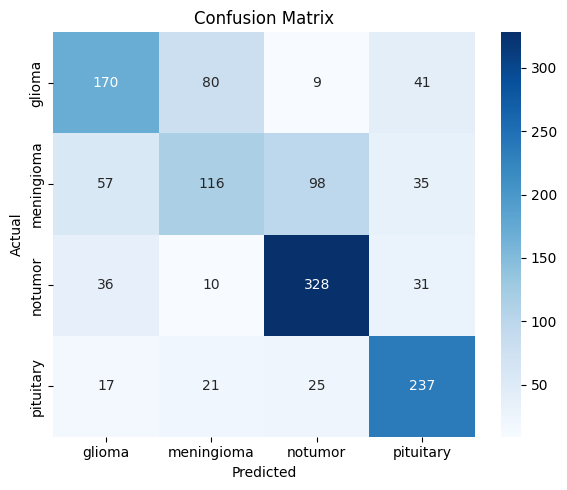

,precision,recall,f1-score,support
glioma,0.607,0.567,0.586,300.000
meningioma,0.511,0.379,0.435,306.000
notumor,0.713,0.810,0.758,405.000
pituitary,0.689,0.790,0.736,300.000
accuracy,0.649,0.649,0.649,0.649
macro avg,0.630,0.636,0.629,1311.000
weighted avg,0.636,0.649,0.638,1311.000


In [31]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd

# Get predicted class indices
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class)
df_cm = pd.DataFrame(cm, index=class_labels, columns=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Classification report (precision, recall, F1)
report = classification_report(y_true_class, y_pred_class, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Round values and print neatly
report_df = report_df.round(3)
display(report_df)

In [32]:
# One-hot encode true labels for AUC
y_true_binarized = label_binarize(y_true_class, classes=np.arange(n_classes))

# Compute macro average metrics
macro_precision = precision_score(y_true_class, y_pred_class, average='macro')
macro_recall = recall_score(y_true_class, y_pred_class, average='macro')
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
macro_auc = roc_auc_score(y_true_binarized, y_pred, average='macro', multi_class='ovr')

# Append ResNet50 results
results_df.loc[len(results_df)] = [
    "ResNet50", 
    test_acc, 
    test_loss, 
    round(macro_precision, 4), 
    round(macro_recall, 4), 
    round(macro_f1, 4), 
    round(macro_auc, 4)
]

# Display the updated results
display(results_df)

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358


## DenseNet121

### Build DenseNet121 Model

In [33]:
from tensorflow.keras.applications import DenseNet121

def build_densenet121_model():
    input_tensor = Input(shape=(224, 224, 1))
    rgb_tensor = Lambda(lambda x: tf.image.grayscale_to_rgb(x))(input_tensor)

    base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=rgb_tensor)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

# Compile the model
model = build_densenet121_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Callback and Training

In [34]:

early_stop = EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("densenet121_brain_tumor.keras", save_best_only=True)

history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 101s 474ms/step - accuracy: 0.4641 - loss: 1.3233 - val_accuracy: 0.6810 - val_loss: 0.9065
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 212ms/step - accuracy: 0.7571 - loss: 0.6496 - val_accuracy: 0.7239 - val_loss: 0.8315
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 209ms/step - accuracy: 0.8047 - loss: 0.5228 - val_accuracy: 0.7292 - val_loss: 0.7718
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 215ms/step - accuracy: 0.8488 - loss: 0.4509 - val_accuracy: 0.7564 - val_loss: 0.7265
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 210ms/step - accuracy: 0.8458 - loss: 0.4217 - val_accuracy: 0.7669 - val_loss: 0.6712
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 214ms/step - accuracy: 0.8534 - loss: 0.4113 - val_accuracy: 0.7642 - val_loss: 0.6618
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 208ms/step - accuracy: 0.8800 - loss: 0.3516 - val_accuracy: 0.7783 - val_loss: 0.6345
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 214ms/step - accuracy: 0.8718 - loss: 

### Test Loss And Accuracy

In [35]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 391ms/step - accuracy: 0.8147 - loss: 0.4412
Test Accuracy: 0.8658
Test Loss: 0.3518


### Train Test Val Loss PLot

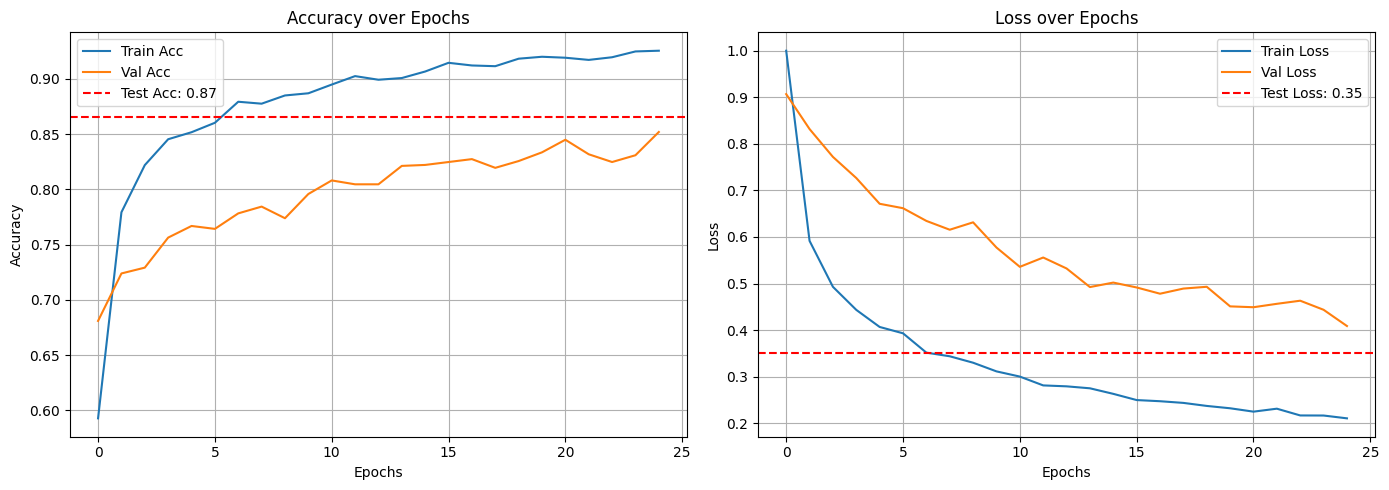

In [36]:
def plot_all_curves(history, test_acc, test_loss):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_all_curves(history, test_acc, test_loss)

### AUC - ROC Curve

41/41 ━━━━━━━━━━━━━━━━━━━━ 26s 372ms/step


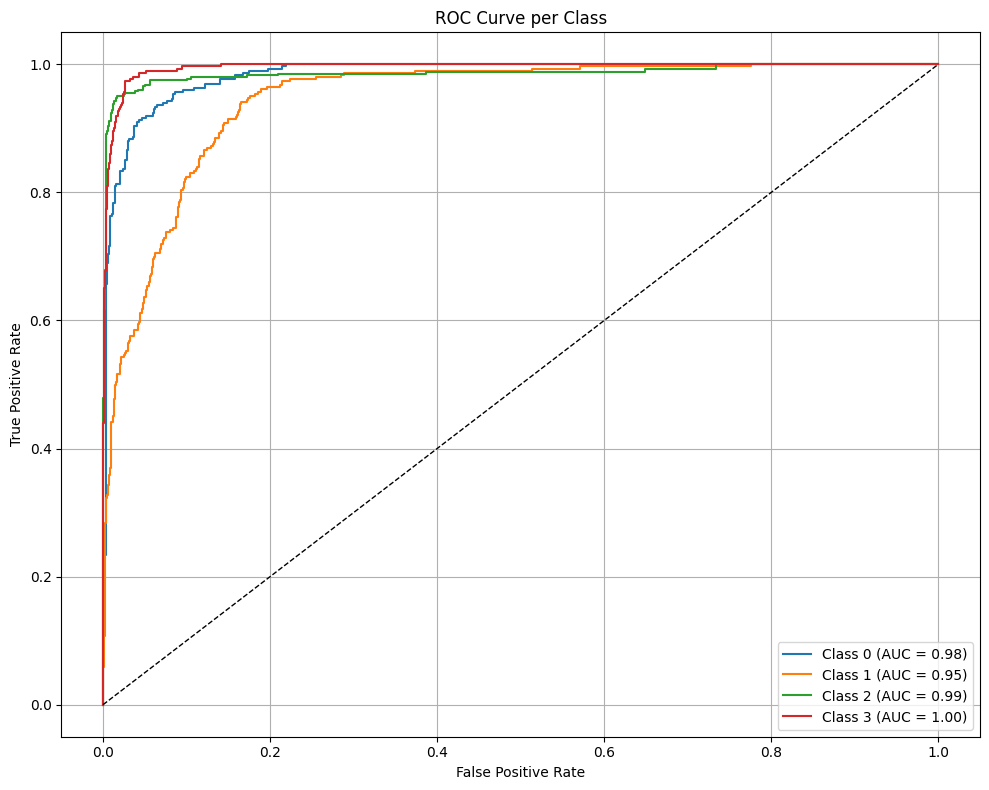

In [37]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Predictions
y_pred = model.predict(test_generator)
y_true = test_generator.classes
n_classes = y_pred.shape[1]

# One-hot encode the true labels
y_true_onehot = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

### Confusion Matrix

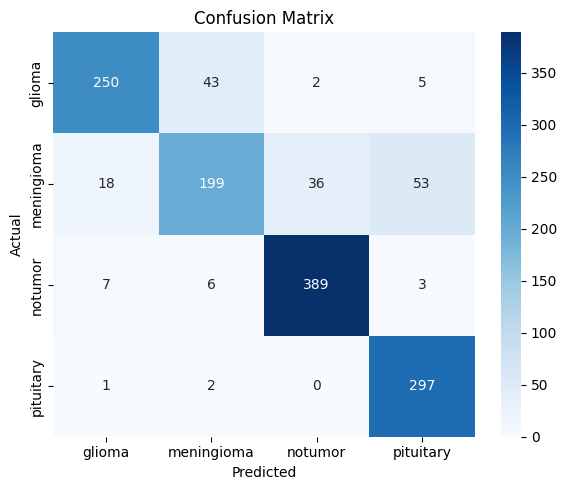

,precision,recall,f1-score,support
glioma,0.906,0.833,0.868,300.000
meningioma,0.796,0.650,0.716,306.000
notumor,0.911,0.960,0.935,405.000
pituitary,0.830,0.990,0.903,300.000
accuracy,0.866,0.866,0.866,0.866
macro avg,0.861,0.859,0.855,1311.000
weighted avg,0.864,0.866,0.861,1311.000


In [38]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd

# Get predicted class indices
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class)
df_cm = pd.DataFrame(cm, index=class_labels, columns=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Classification report (precision, recall, F1)
report = classification_report(y_true_class, y_pred_class, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Round values and print neatly
report_df = report_df.round(3)
display(report_df)

In [39]:
# One-hot encode true labels for AUC
y_true_binarized = label_binarize(y_true_class, classes=np.arange(n_classes))

# Compute macro average metrics
macro_precision = precision_score(y_true_class, y_pred_class, average='macro')
macro_recall = recall_score(y_true_class, y_pred_class, average='macro')
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
macro_auc = roc_auc_score(y_true_binarized, y_pred, average='macro', multi_class='ovr')

# Append DenseNet121 results
results_df.loc[len(results_df)] = [
    "DenseNet121", 
    test_acc, 
    test_loss, 
    round(macro_precision, 4), 
    round(macro_recall, 4), 
    round(macro_f1, 4), 
    round(macro_auc, 4)
]

# Display the updated results
display(results_df)

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358
2,DenseNet121,0.865751,0.351833,0.8606,0.8585,0.8554,0.9781


## EfficientNetB0

### Build Efficientnet Model

In [40]:
def build_efficientnetb0_model():
    input_tensor = Input(shape=(224, 224, 1))
    rgb_tensor = Lambda(lambda x: tf.image.grayscale_to_rgb(x))(input_tensor)

    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=rgb_tensor)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

# Compile the model
model = build_efficientnetb0_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### CallBack and Train the model

In [41]:


early_stop = EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("efficientnetb0_brain_tumor.keras", save_best_only=True)

history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 79s 365ms/step - accuracy: 0.2629 - loss: 1.3848 - val_accuracy: 0.2796 - val_loss: 1.3840
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 28s 191ms/step - accuracy: 0.2755 - loss: 1.3844 - val_accuracy: 0.2752 - val_loss: 1.3841
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 30s 199ms/step - accuracy: 0.2693 - loss: 1.3855 - val_accuracy: 0.2796 - val_loss: 1.3833
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 29s 195ms/step - accuracy: 0.2770 - loss: 1.3858 - val_accuracy: 0.2796 - val_loss: 1.3836
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 30s 203ms/step - accuracy: 0.2639 - loss: 1.3875 - val_accuracy: 0.2796 - val_loss: 1.3832
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 29s 194ms/step - accuracy: 0.2628 - loss: 1.3844 - val_accuracy: 0.2796 - val_loss: 1.3836
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 30s 200ms/step - accuracy: 0.2748 - loss: 1.3850 - val_accuracy: 0.2796 - val_loss: 1.3837
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 29s 197ms/step - accuracy: 0.2615 - loss: 1

### Test Loss and accuracy

In [42]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 194ms/step - accuracy: 0.1600 - loss: 1.4247
Test Accuracy: 0.3089
Test Loss: 1.3785


### Train Test Val Loss

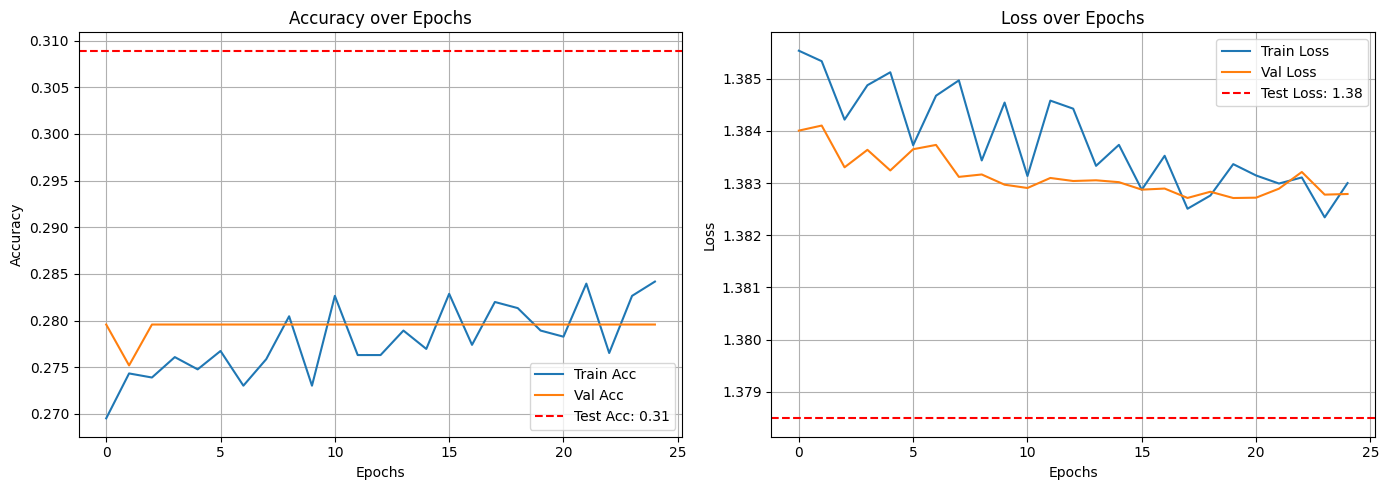

In [43]:
def plot_all_curves(history, test_acc, test_loss):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_all_curves(history, test_acc, test_loss)

### AUC - ROC Curve

41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 217ms/step


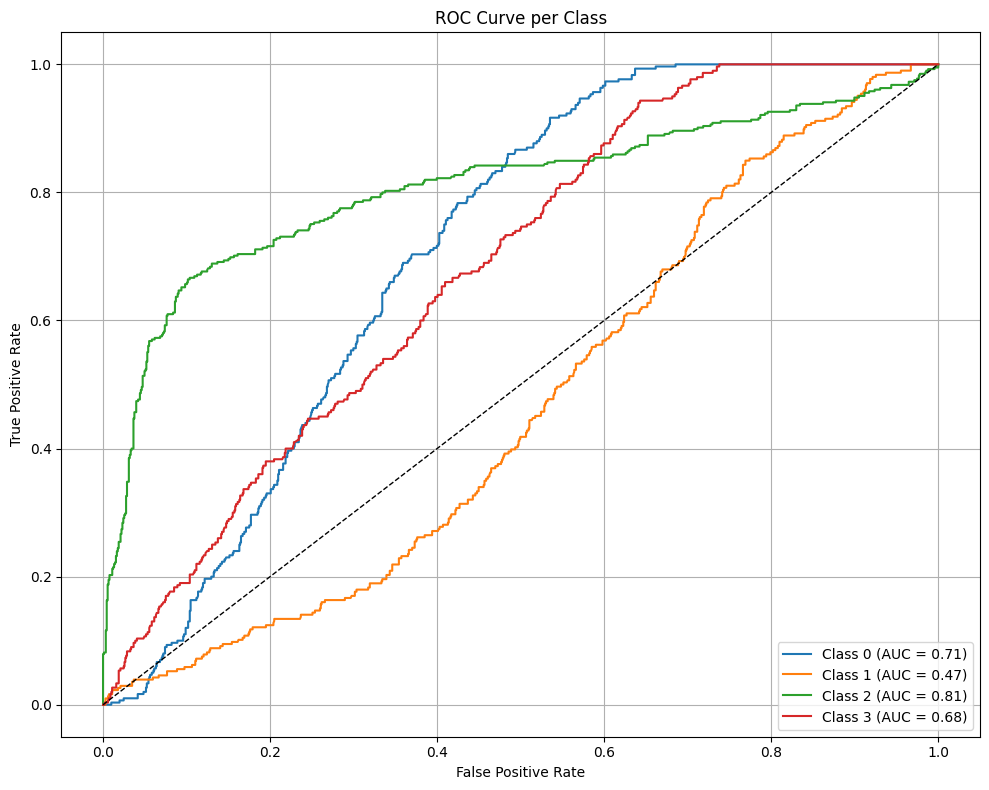

In [44]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Predictions
y_pred = model.predict(test_generator)
y_true = test_generator.classes
n_classes = y_pred.shape[1]

# One-hot encode the true labels
y_true_onehot = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

### Confusion Matrix

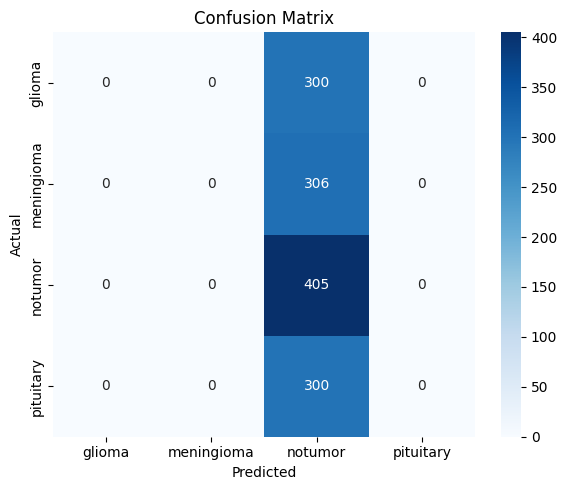

,precision,recall,f1-score,support
glioma,0.000,0.000,0.000,300.000
meningioma,0.000,0.000,0.000,306.000
notumor,0.309,1.000,0.472,405.000
pituitary,0.000,0.000,0.000,300.000
accuracy,0.309,0.309,0.309,0.309
macro avg,0.077,0.250,0.118,1311.000
weighted avg,0.095,0.309,0.146,1311.000


In [45]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd

# Get predicted class indices
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class)
df_cm = pd.DataFrame(cm, index=class_labels, columns=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Classification report (precision, recall, F1)
report = classification_report(y_true_class, y_pred_class, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Round values and print neatly
report_df = report_df.round(3)
display(report_df)

In [46]:
# One-hot encode true labels for AUC
y_true_binarized = label_binarize(y_true_class, classes=np.arange(n_classes))

# Compute macro average metrics
macro_precision = precision_score(y_true_class, y_pred_class, average='macro')
macro_recall = recall_score(y_true_class, y_pred_class, average='macro')
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
macro_auc = roc_auc_score(y_true_binarized, y_pred, average='macro', multi_class='ovr')

# Append EfficientNetB0 results
results_df.loc[len(results_df)] = [
    "EfficientNetB0", 
    test_acc, 
    test_loss, 
    round(macro_precision, 4), 
    round(macro_recall, 4), 
    round(macro_f1, 4), 
    round(macro_auc, 4)
]

# Display the updated results
display(results_df)


,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358
2,DenseNet121,0.865751,0.351833,0.8606,0.8585,0.8554,0.9781
3,EfficientNetB0,0.308924,1.378495,0.0772,0.2500,0.1180,0.6661


In [47]:
results_df = results_df[results_df['Model'] != "EfficientNetB0="].reset_index(drop=True)

# Display the cleaned DataFrame
display(results_df)

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358
2,DenseNet121,0.865751,0.351833,0.8606,0.8585,0.8554,0.9781
3,EfficientNetB0,0.308924,1.378495,0.0772,0.2500,0.1180,0.6661


In [48]:
results_df

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358
2,DenseNet121,0.865751,0.351833,0.8606,0.8585,0.8554,0.9781
3,EfficientNetB0,0.308924,1.378495,0.0772,0.2500,0.1180,0.6661


## MobileNetV2

### Build and Compile MobileNetV2

In [49]:
from tensorflow.keras.applications import MobileNetV2

def build_mobilenetv2_model():
    input_tensor = Input(shape=(224, 224, 1))
    rgb_tensor = Lambda(lambda x: tf.image.grayscale_to_rgb(x))(input_tensor)

    base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=rgb_tensor)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

# Compile the model
model = build_mobilenetv2_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### Callback and train the model

In [50]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("mobilenetv2_brain_tumor.keras", save_best_only=True)

history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 51s 267ms/step - accuracy: 0.4967 - loss: 1.2030 - val_accuracy: 0.6784 - val_loss: 0.8604
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 29s 196ms/step - accuracy: 0.7977 - loss: 0.5465 - val_accuracy: 0.7388 - val_loss: 0.7795
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 30s 201ms/step - accuracy: 0.8347 - loss: 0.4417 - val_accuracy: 0.7572 - val_loss: 0.6535
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 29s 194ms/step - accuracy: 0.8723 - loss: 0.3710 - val_accuracy: 0.7713 - val_loss: 0.6321
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 30s 201ms/step - accuracy: 0.8872 - loss: 0.3368 - val_accuracy: 0.7809 - val_loss: 0.5822
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 29s 195ms/step - accuracy: 0.8913 - loss: 0.3266 - val_accuracy: 0.7862 - val_loss: 0.5645
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 29s 198ms/step - accuracy: 0.9052 - loss: 0.2930 - val_accuracy: 0.7888 - val_loss: 0.5584
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 29s 197ms/step - accuracy: 0.8894 - loss: 0

### Test and Loss Accuracy

In [51]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.7944 - loss: 0.5088
Test Accuracy: 0.8619
Test Loss: 0.3626


### Train Test Val Loss

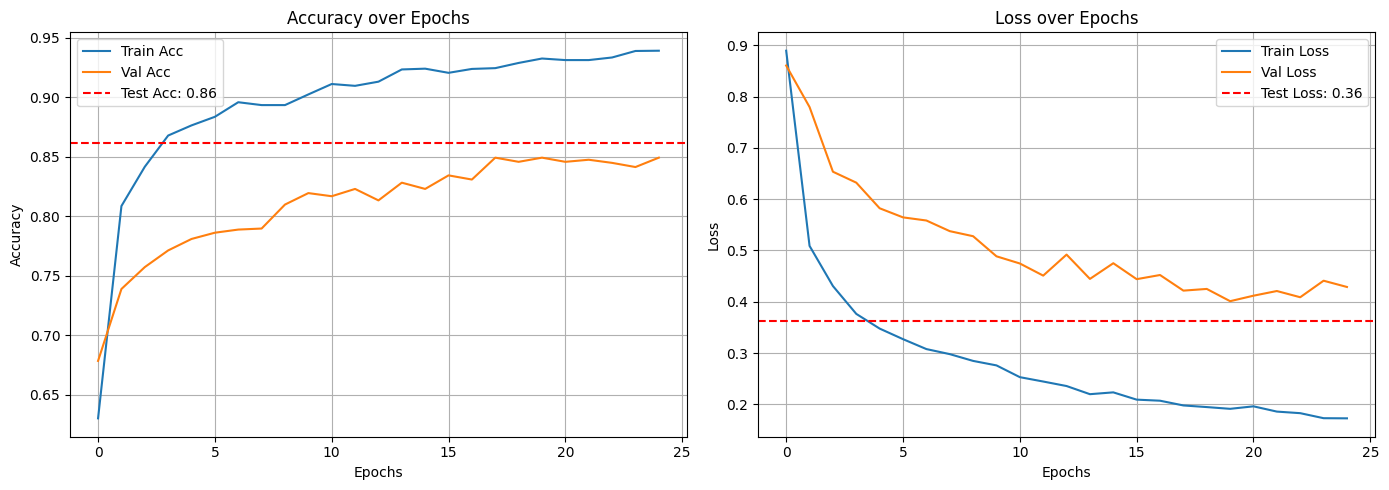

In [52]:
def plot_all_curves(history, test_acc, test_loss):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_all_curves(history, test_acc, test_loss)

### AUC - ROC Curve

41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step


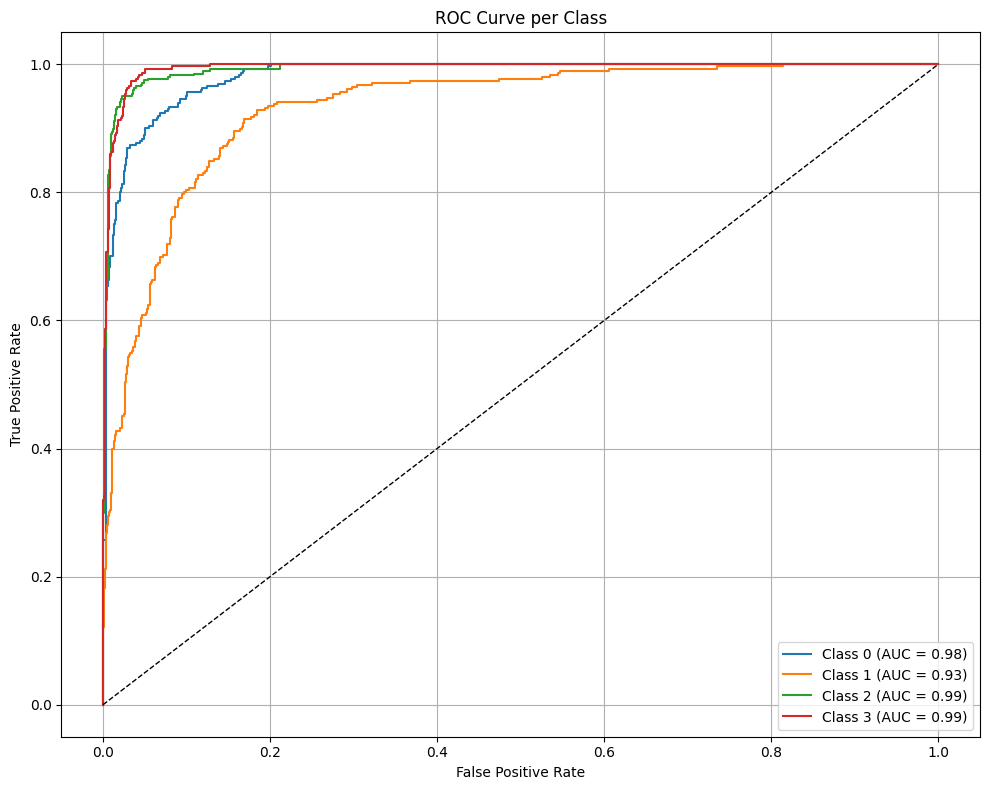

In [53]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Predictions
y_pred = model.predict(test_generator)
y_true = test_generator.classes
n_classes = y_pred.shape[1]

# One-hot encode the true labels
y_true_onehot = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

### Confusion Matrix

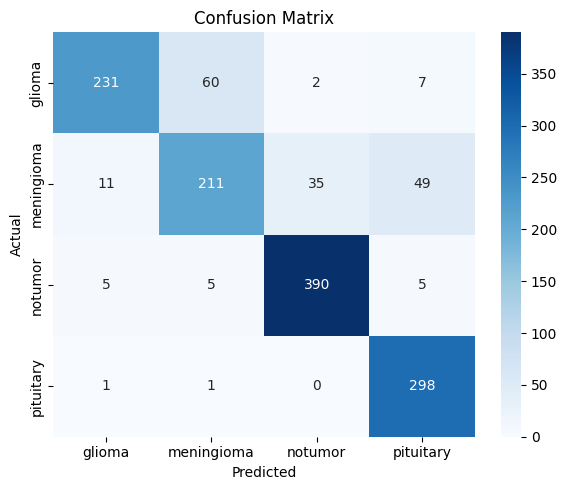

,precision,recall,f1-score,support
glioma,0.931,0.770,0.843,300.000
meningioma,0.762,0.690,0.724,306.000
notumor,0.913,0.963,0.938,405.000
pituitary,0.830,0.993,0.904,300.000
accuracy,0.862,0.862,0.862,0.862
macro avg,0.859,0.854,0.852,1311.000
weighted avg,0.863,0.862,0.858,1311.000


In [54]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd

# Get predicted class indices
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class)
df_cm = pd.DataFrame(cm, index=class_labels, columns=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Classification report (precision, recall, F1)
report = classification_report(y_true_class, y_pred_class, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Round values and print neatly
report_df = report_df.round(3)
display(report_df)

In [55]:
# One-hot encode true labels for AUC
y_true_binarized = label_binarize(y_true_class, classes=np.arange(n_classes))

# Compute macro average metrics
macro_precision = precision_score(y_true_class, y_pred_class, average='macro')
macro_recall = recall_score(y_true_class, y_pred_class, average='macro')
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
macro_auc = roc_auc_score(y_true_binarized, y_pred, average='macro', multi_class='ovr')

# Append MobileNetV2 results
results_df.loc[len(results_df)] = [
    "MobileNetV2", 
    test_acc, 
    test_loss, 
    round(macro_precision, 4), 
    round(macro_recall, 4), 
    round(macro_f1, 4), 
    round(macro_auc, 4)
]

# Display the updated results
display(results_df)

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358
2,DenseNet121,0.865751,0.351833,0.8606,0.8585,0.8554,0.9781
3,EfficientNetB0,0.308924,1.378495,0.0772,0.2500,0.1180,0.6661
4,MobileNetV2,0.861937,0.362561,0.8592,0.8540,0.8522,0.9755


In [56]:
# Drop the duplicate MobileNetV2 row (if present)
results_df = results_df.drop_duplicates(subset=["Model"], keep="first").reset_index(drop=True)

# Display cleaned DataFrame
display(results_df)

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358
2,DenseNet121,0.865751,0.351833,0.8606,0.8585,0.8554,0.9781
3,EfficientNetB0,0.308924,1.378495,0.0772,0.2500,0.1180,0.6661
4,MobileNetV2,0.861937,0.362561,0.8592,0.8540,0.8522,0.9755


In [57]:
results_df

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358
2,DenseNet121,0.865751,0.351833,0.8606,0.8585,0.8554,0.9781
3,EfficientNetB0,0.308924,1.378495,0.0772,0.2500,0.1180,0.6661
4,MobileNetV2,0.861937,0.362561,0.8592,0.8540,0.8522,0.9755


## InceptionV3

### Build the Model

In [58]:
from tensorflow.keras.applications import InceptionV3

def build_inceptionv3_model():
    input_tensor = Input(shape=(224, 224, 1))
    rgb_tensor = Lambda(lambda x: tf.image.grayscale_to_rgb(x))(input_tensor)

    base_model = InceptionV3(weights='imagenet', include_top=False, input_tensor=rgb_tensor)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

# Compile the model
model = build_inceptionv3_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


### Callback and Train Model

In [59]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("inceptionv3_brain_tumor.keras", save_best_only=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 72s 357ms/step - accuracy: 0.5475 - loss: 1.1060 - val_accuracy: 0.6740 - val_loss: 0.8506
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 213ms/step - accuracy: 0.7856 - loss: 0.5785 - val_accuracy: 0.7283 - val_loss: 0.7282
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 211ms/step - accuracy: 0.8237 - loss: 0.4781 - val_accuracy: 0.7388 - val_loss: 0.6855
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 210ms/step - accuracy: 0.8375 - loss: 0.4259 - val_accuracy: 0.7441 - val_loss: 0.6947
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 213ms/step - accuracy: 0.8519 - loss: 0.4022 - val_accuracy: 0.7616 - val_loss: 0.5874
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 210ms/step - accuracy: 0.8673 - loss: 0.3680 - val_accuracy: 0.7634 - val_loss: 0.6220
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 30s 203ms/step - accuracy: 0.8688 - loss: 0.3716 - val_accuracy: 0.7791 - val_loss: 0.6135
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 213ms/step - accuracy: 0.8633 - loss: 0

### Test And Loss Accuracy

In [60]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 241ms/step - accuracy: 0.8371 - loss: 0.3916
Test Accuracy: 0.8810
Test Loss: 0.3066


### Train Test Val Plot

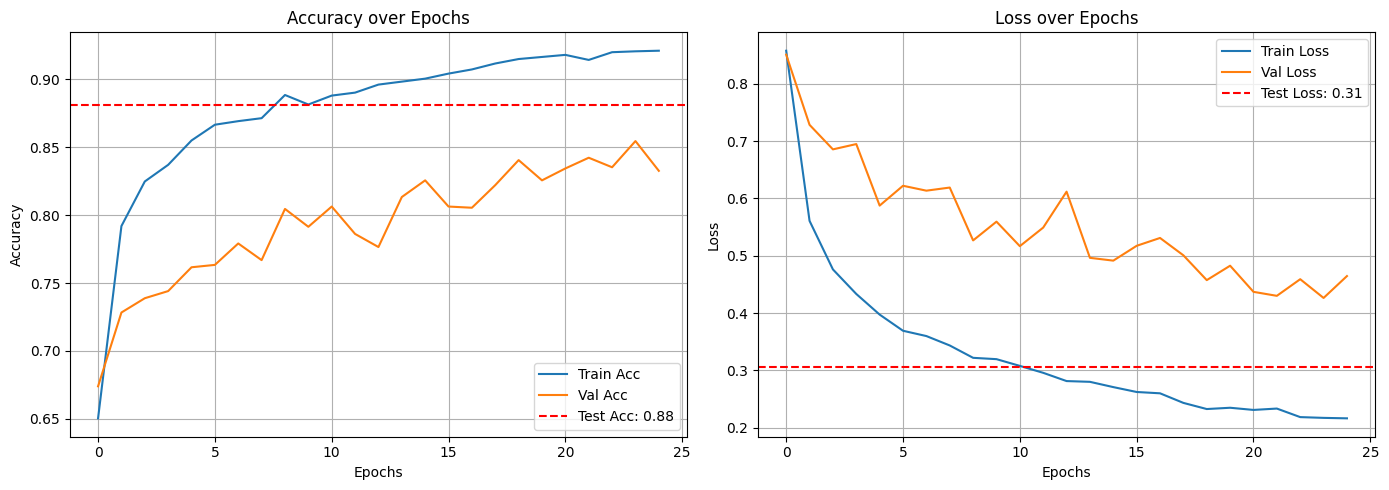

In [61]:
def plot_all_curves(history, test_acc, test_loss):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_all_curves(history, test_acc, test_loss)

### AUC - ROC Curve

41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 223ms/step


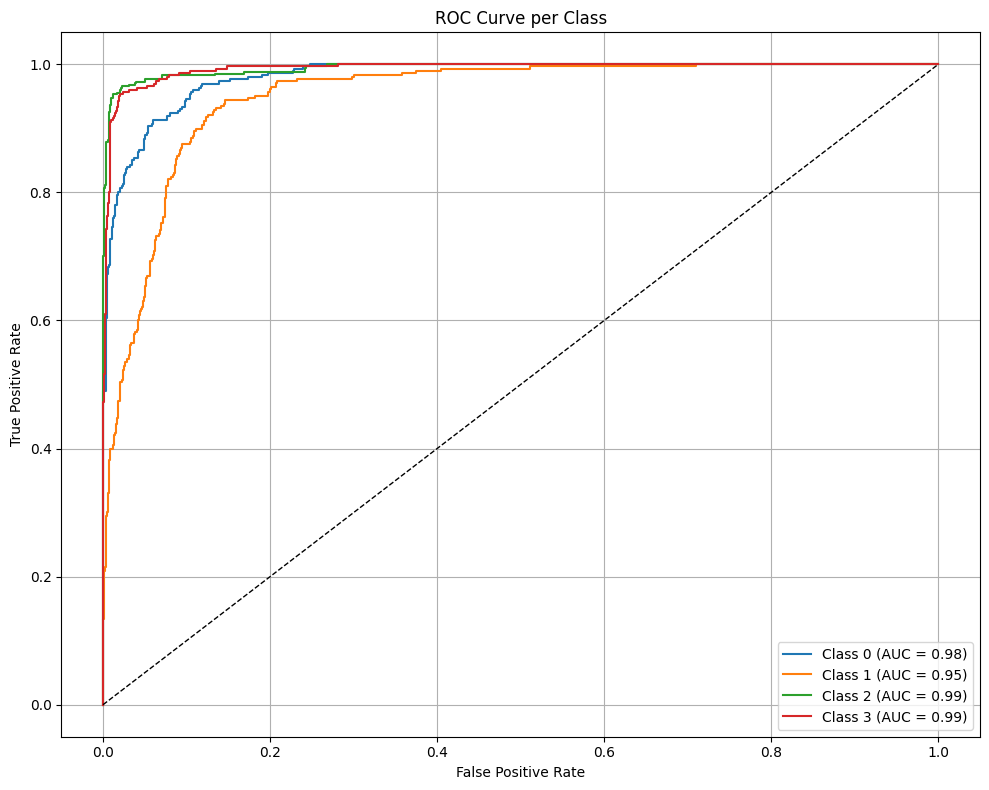

In [62]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Predictions
y_pred = model.predict(test_generator)
y_true = test_generator.classes
n_classes = y_pred.shape[1]

# One-hot encode the true labels
y_true_onehot = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

### Confusion Matrix

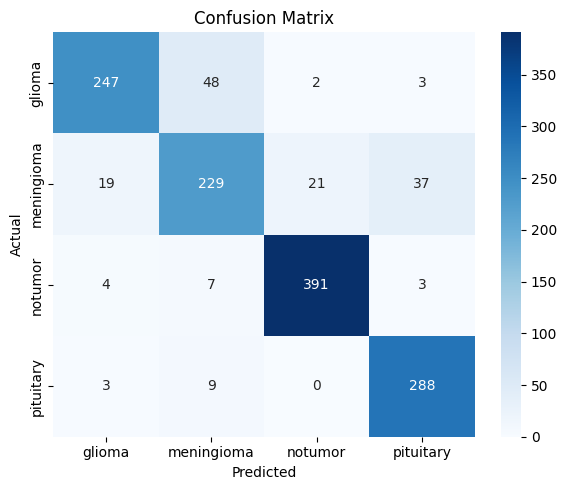

,precision,recall,f1-score,support
glioma,0.905,0.823,0.862,300.000
meningioma,0.782,0.748,0.765,306.000
notumor,0.944,0.965,0.955,405.000
pituitary,0.870,0.960,0.913,300.000
accuracy,0.881,0.881,0.881,0.881
macro avg,0.875,0.874,0.874,1311.000
weighted avg,0.880,0.881,0.880,1311.000


In [63]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd

# Get predicted class indices
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class)
df_cm = pd.DataFrame(cm, index=class_labels, columns=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Classification report (precision, recall, F1)
report = classification_report(y_true_class, y_pred_class, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Round values and print neatly
report_df = report_df.round(3)
display(report_df)

In [64]:
# # Ensure DataFrame has correct structure
# try:
#     results_df
# except NameError:
#     results_df = pd.DataFrame(columns=[
#         "Model", "Test Accuracy", "Test Loss", "F1-Score", "AUC"
#     ])

# # One-hot encode true labels for AUC
# y_true_binarized = label_binarize(y_true_class, classes=np.arange(n_classes))

# # Compute F1 and AUC
# macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
# macro_auc = roc_auc_score(y_true_binarized, y_pred, average='macro', multi_class='ovr')

# # Append InceptionV3 results
# results_df.loc[len(results_df)] = [
#     "InceptionV3", 
#     test_acc, 
#     test_loss, 
#     round(macro_f1, 4), 
#     round(macro_auc, 4)
# ]

# # Display the updated DataFrame
# display(results_df)
# One-hot encode true labels for AUC
y_true_binarized = label_binarize(y_true_class, classes=np.arange(n_classes))

# Compute macro average metrics
macro_precision = precision_score(y_true_class, y_pred_class, average='macro')
macro_recall = recall_score(y_true_class, y_pred_class, average='macro')
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
macro_auc = roc_auc_score(y_true_binarized, y_pred, average='macro', multi_class='ovr')

# Append MobileNetV2 results
results_df.loc[len(results_df)] = [
    "InceptionV3", 
    test_acc, 
    test_loss, 
    round(macro_precision, 4), 
    round(macro_recall, 4), 
    round(macro_f1, 4), 
    round(macro_auc, 4)
]

# Display the updated results
display(results_df)

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358
2,DenseNet121,0.865751,0.351833,0.8606,0.8585,0.8554,0.9781
3,EfficientNetB0,0.308924,1.378495,0.0772,0.2500,0.1180,0.6661
4,MobileNetV2,0.861937,0.362561,0.8592,0.8540,0.8522,0.9755
5,InceptionV3,0.881007,0.306638,0.8752,0.8743,0.8736,0.9800


## Xception

### Build the Model

In [65]:
from tensorflow.keras.applications import Xception
def build_xception_model():
    input_tensor = Input(shape=(224, 224, 1))
    rgb_tensor = Lambda(lambda x: tf.image.grayscale_to_rgb(x))(input_tensor)

    base_model = Xception(weights='imagenet', include_top=False, input_tensor=rgb_tensor)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

# Compile the model
model = build_xception_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


### Callbacks and Train

In [66]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("xception_brain_tumor.keras", save_best_only=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 61s 331ms/step - accuracy: 0.5499 - loss: 1.0428 - val_accuracy: 0.7064 - val_loss: 0.8332
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 236ms/step - accuracy: 0.8107 - loss: 0.5205 - val_accuracy: 0.7485 - val_loss: 0.7240
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 218ms/step - accuracy: 0.8440 - loss: 0.4434 - val_accuracy: 0.7826 - val_loss: 0.6140
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 225ms/step - accuracy: 0.8548 - loss: 0.3995 - val_accuracy: 0.7695 - val_loss: 0.5976
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 223ms/step - accuracy: 0.8654 - loss: 0.3667 - val_accuracy: 0.7862 - val_loss: 0.5614
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 222ms/step - accuracy: 0.8791 - loss: 0.3419 - val_accuracy: 0.8011 - val_loss: 0.5425
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 217ms/step - accuracy: 0.8769 - loss: 0.3553 - val_accuracy: 0.8089 - val_loss: 0.5326
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.8979 - loss: 0

### Test and Loss Accuracy

In [67]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - accuracy: 0.8448 - loss: 0.3858
Test Accuracy: 0.8833
Test Loss: 0.3102


### Train Test Loss Curve

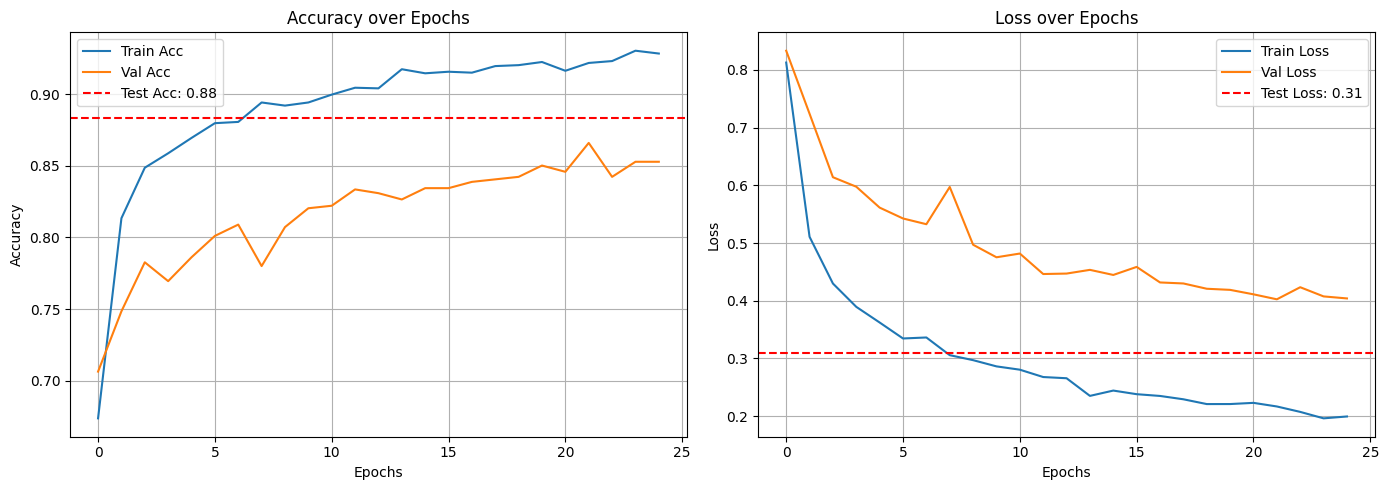

In [68]:
def plot_all_curves(history, test_acc, test_loss):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_all_curves(history, test_acc, test_loss)

### AUC - ROC Curve

41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step


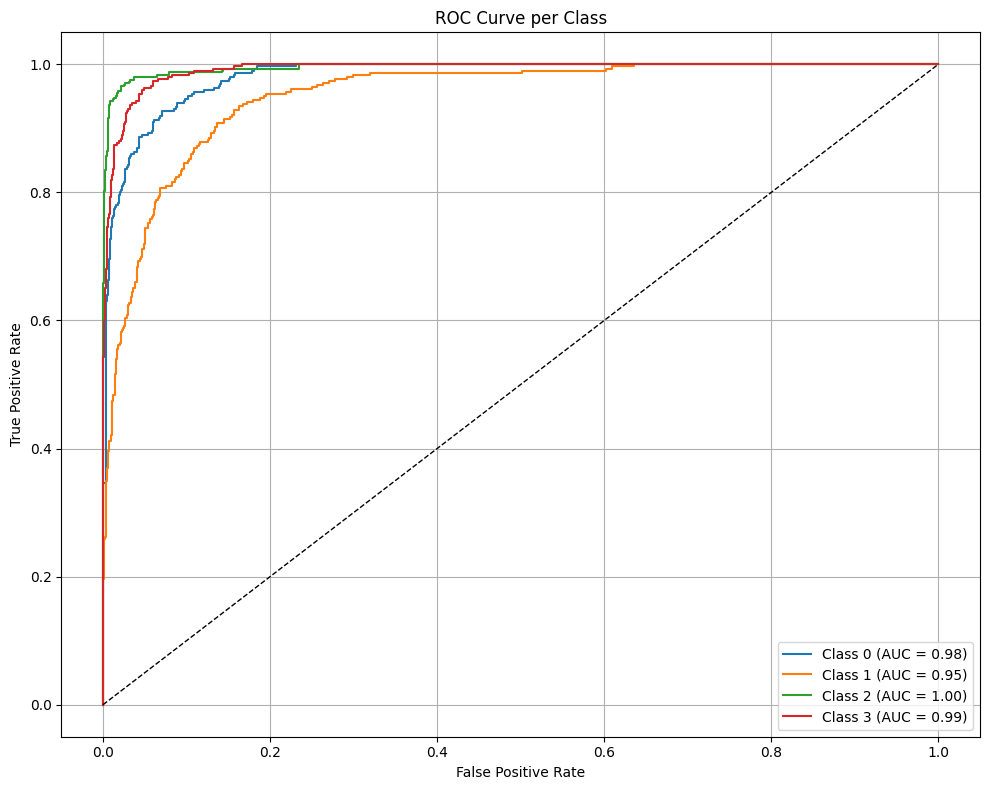

In [69]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Predictions
y_pred = model.predict(test_generator)
y_true = test_generator.classes
n_classes = y_pred.shape[1]

# One-hot encode the true labels
y_true_onehot = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

### Confusion Matrix

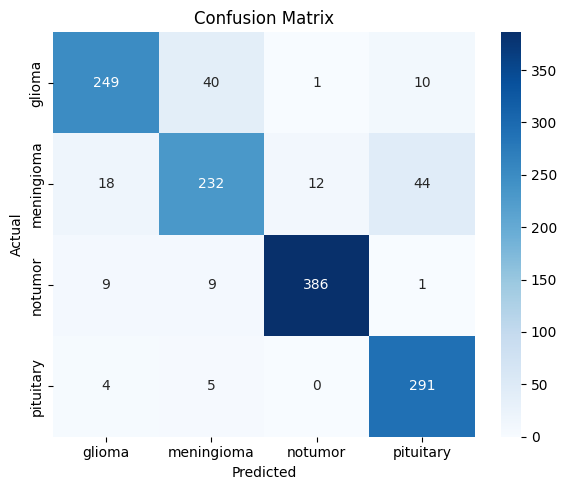

,precision,recall,f1-score,support
glioma,0.889,0.830,0.859,300.000
meningioma,0.811,0.758,0.784,306.000
notumor,0.967,0.953,0.960,405.000
pituitary,0.841,0.970,0.901,300.000
accuracy,0.883,0.883,0.883,0.883
macro avg,0.877,0.878,0.876,1311.000
weighted avg,0.884,0.883,0.882,1311.000


In [70]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd

# Get predicted class indices
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class)
df_cm = pd.DataFrame(cm, index=class_labels, columns=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Classification report (precision, recall, F1)
report = classification_report(y_true_class, y_pred_class, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Round values and print neatly
report_df = report_df.round(3)
display(report_df)

In [71]:
y_true_binarized = label_binarize(y_true_class, classes=np.arange(n_classes))

# Compute macro average metrics
macro_precision = precision_score(y_true_class, y_pred_class, average='macro')
macro_recall = recall_score(y_true_class, y_pred_class, average='macro')
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
macro_auc = roc_auc_score(y_true_binarized, y_pred, average='macro', multi_class='ovr')

# Append MobileNetV2 results
results_df.loc[len(results_df)] = [
    "Xception", 
    test_acc, 
    test_loss, 
    round(macro_precision, 4), 
    round(macro_recall, 4), 
    round(macro_f1, 4), 
    round(macro_auc, 4)
]

# Display the updated results
display(results_df)

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358
2,DenseNet121,0.865751,0.351833,0.8606,0.8585,0.8554,0.9781
3,EfficientNetB0,0.308924,1.378495,0.0772,0.2500,0.1180,0.6661
4,MobileNetV2,0.861937,0.362561,0.8592,0.8540,0.8522,0.9755
5,InceptionV3,0.881007,0.306638,0.8752,0.8743,0.8736,0.9800
6,Xception,0.883295,0.310204,0.8772,0.8778,0.8759,0.9803


### NASNetMobile

In [72]:
from tensorflow.keras.applications import NASNetMobile

def build_nasnetmobile_model():
    input_tensor = Input(shape=(224, 224, 1))
    rgb_tensor = Lambda(lambda x: tf.image.grayscale_to_rgb(x))(input_tensor)

    base_model = NASNetMobile(weights='imagenet', include_top=False, input_tensor=rgb_tensor)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

# Compile the model
model = build_nasnetmobile_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Train with Callbacks

In [73]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("nasnetmobile_brain_tumor.keras", save_best_only=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 108s 450ms/step - accuracy: 0.4507 - loss: 1.2651 - val_accuracy: 0.6731 - val_loss: 0.8887
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 216ms/step - accuracy: 0.7289 - loss: 0.7050 - val_accuracy: 0.6933 - val_loss: 0.8174
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 214ms/step - accuracy: 0.7798 - loss: 0.5807 - val_accuracy: 0.7143 - val_loss: 0.7881
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 217ms/step - accuracy: 0.8196 - loss: 0.5094 - val_accuracy: 0.7160 - val_loss: 0.7734
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 223ms/step - accuracy: 0.8180 - loss: 0.4840 - val_accuracy: 0.7239 - val_loss: 0.7289
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 216ms/step - accuracy: 0.8312 - loss: 0.4548 - val_accuracy: 0.7415 - val_loss: 0.6692
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 218ms/step - accuracy: 0.8424 - loss: 0.4203 - val_accuracy: 0.7388 - val_loss: 0.6626
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 217ms/step - accuracy: 0.8490 - loss: 


### Test Accuracy and Loss

In [74]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 255ms/step - accuracy: 0.7834 - loss: 0.5310
Test Accuracy: 0.8345
Test Loss: 0.4257


### Train Test and val plot

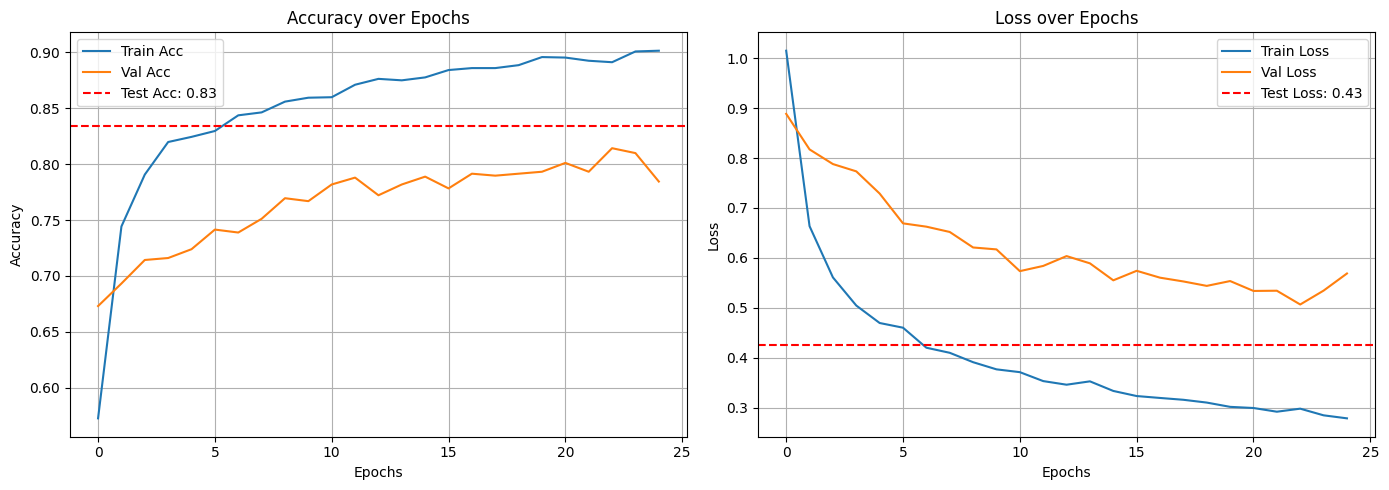

In [75]:
def plot_all_curves(history, test_acc, test_loss):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_all_curves(history, test_acc, test_loss)

### AUC - ROC Curve

41/41 ━━━━━━━━━━━━━━━━━━━━ 32s 422ms/step


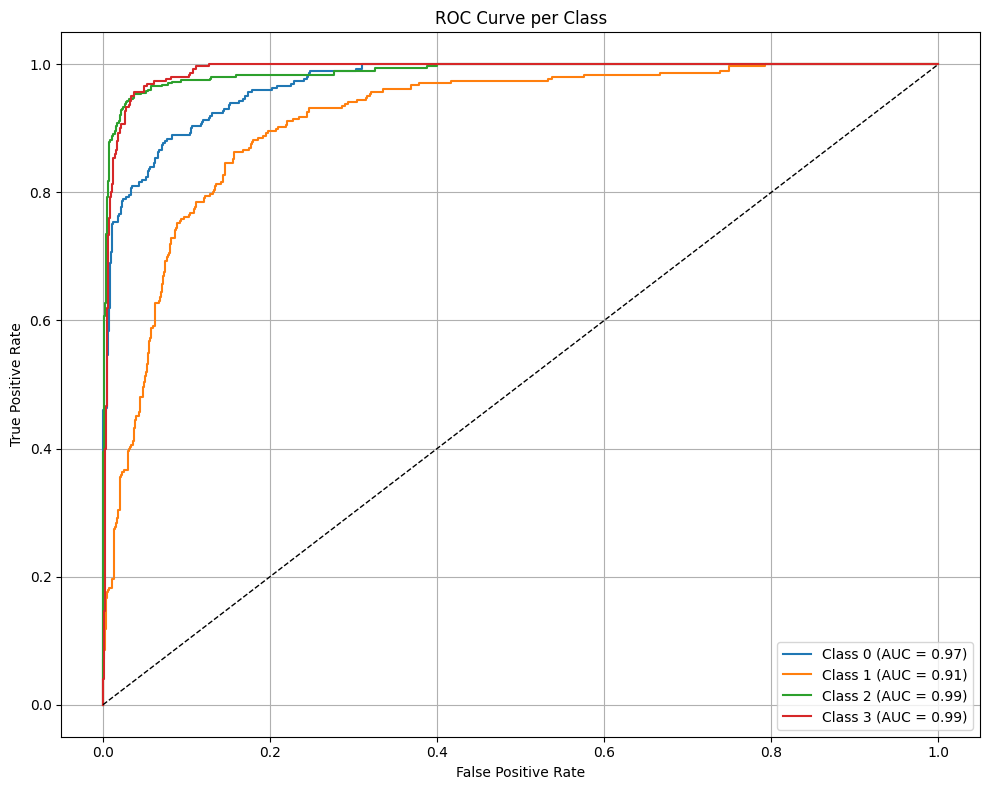

In [76]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Predictions
y_pred = model.predict(test_generator)
y_true = test_generator.classes
n_classes = y_pred.shape[1]

# One-hot encode the true labels
y_true_onehot = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

### Confusion Matrix

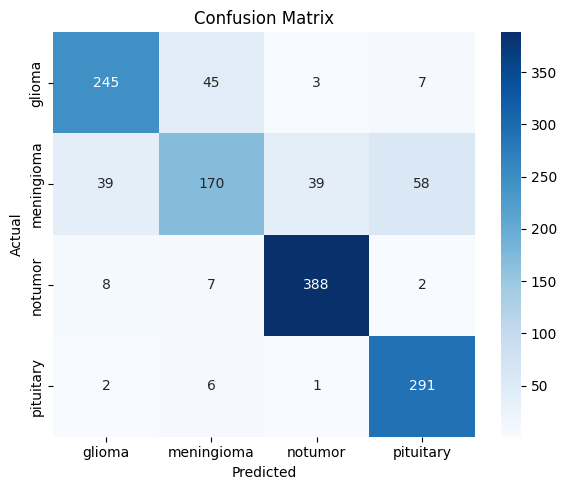

,precision,recall,f1-score,support
glioma,0.833,0.817,0.825,300.000
meningioma,0.746,0.556,0.637,306.000
notumor,0.900,0.958,0.928,405.000
pituitary,0.813,0.970,0.884,300.000
accuracy,0.834,0.834,0.834,0.834
macro avg,0.823,0.825,0.819,1311.000
weighted avg,0.829,0.834,0.827,1311.000


In [77]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd

# Get predicted class indices
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class)
df_cm = pd.DataFrame(cm, index=class_labels, columns=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Classification report (precision, recall, F1)
report = classification_report(y_true_class, y_pred_class, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Round values and print neatly
report_df = report_df.round(3)
display(report_df)

In [79]:
y_true_binarized = label_binarize(y_true_class, classes=np.arange(n_classes))

# Compute macro average metrics
macro_precision = precision_score(y_true_class, y_pred_class, average='macro')
macro_recall = recall_score(y_true_class, y_pred_class, average='macro')
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
macro_auc = roc_auc_score(y_true_binarized, y_pred, average='macro', multi_class='ovr')

# Append MobileNetV2 results
results_df.loc[len(results_df)] = [
    "NASANetMobile", 
    test_acc, 
    test_loss, 
    round(macro_precision, 4), 
    round(macro_recall, 4), 
    round(macro_f1, 4), 
    round(macro_auc, 4)
]

# Display the updated results
display(results_df)

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358
2,DenseNet121,0.865751,0.351833,0.8606,0.8585,0.8554,0.9781
3,EfficientNetB0,0.308924,1.378495,0.0772,0.2500,0.1180,0.6661
4,MobileNetV2,0.861937,0.362561,0.8592,0.8540,0.8522,0.9755
5,InceptionV3,0.881007,0.306638,0.8752,0.8743,0.8736,0.9800
6,Xception,0.883295,0.310204,0.8772,0.8778,0.8759,0.9803
7,NASANetMobile,0.834477,0.425686,0.8230,0.8251,0.8186,0.9664


### InceptionResNetV2

### Build the Model

In [80]:
from tensorflow.keras.applications import InceptionResNetV2

In [81]:
def build_inceptionresnetv2_model():
    input_tensor = Input(shape=(224, 224, 1))
    rgb_tensor = Lambda(lambda x: tf.image.grayscale_to_rgb(x))(input_tensor)

    base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_tensor=rgb_tensor)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

# Compile the model
model = build_inceptionresnetv2_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [82]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("inceptionresnetv2_brain_tumor.keras", save_best_only=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 103s 463ms/step - accuracy: 0.5357 - loss: 1.1690 - val_accuracy: 0.6626 - val_loss: 0.9661
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 239ms/step - accuracy: 0.7765 - loss: 0.5706 - val_accuracy: 0.6976 - val_loss: 0.8029
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 225ms/step - accuracy: 0.8166 - loss: 0.5041 - val_accuracy: 0.7152 - val_loss: 0.8168
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 36s 242ms/step - accuracy: 0.8463 - loss: 0.4371 - val_accuracy: 0.7195 - val_loss: 0.7498
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 239ms/step - accuracy: 0.8468 - loss: 0.4143 - val_accuracy: 0.7362 - val_loss: 0.7290
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 238ms/step - accuracy: 0.8488 - loss: 0.4294 - val_accuracy: 0.7450 - val_loss: 0.6715
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 221ms/step - accuracy: 0.8639 - loss: 0.3807 - val_accuracy: 0.7432 - val_loss: 0.7113
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 36s 244ms/step - accuracy: 0.8590 - loss: 

### Accuracy  and Loss of Test Dataset

In [83]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 268ms/step - accuracy: 0.8060 - loss: 0.4946
Test Accuracy: 0.8680
Test Loss: 0.3694


### Train Test and Loss Plot

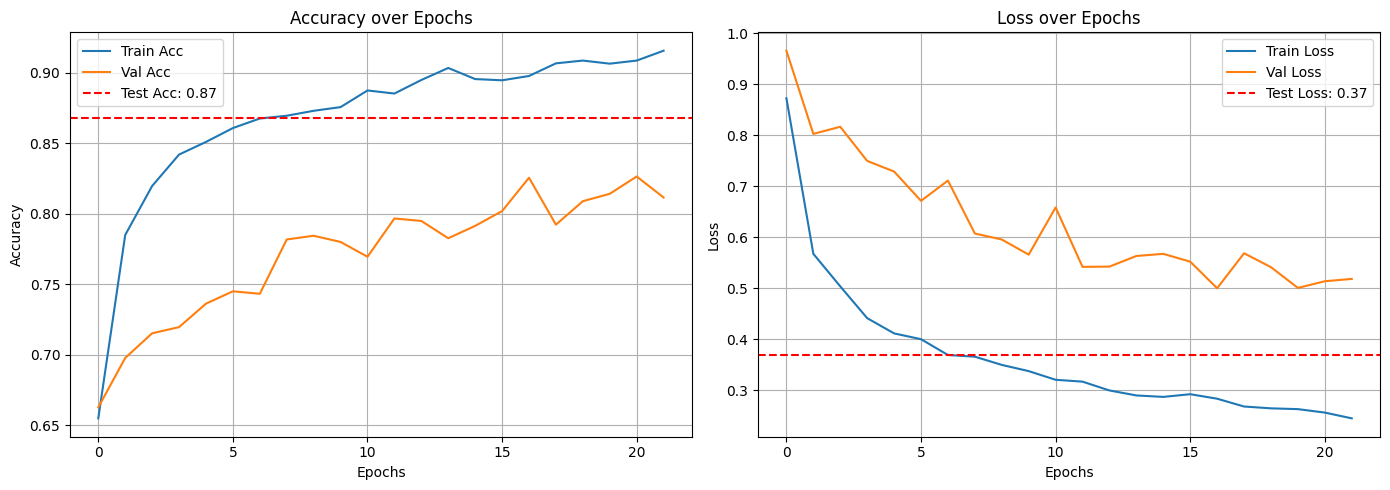

In [84]:
def plot_all_curves(history, test_acc, test_loss):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_all_curves(history, test_acc, test_loss)

### AUC - ROC Curve

41/41 ━━━━━━━━━━━━━━━━━━━━ 31s 416ms/step


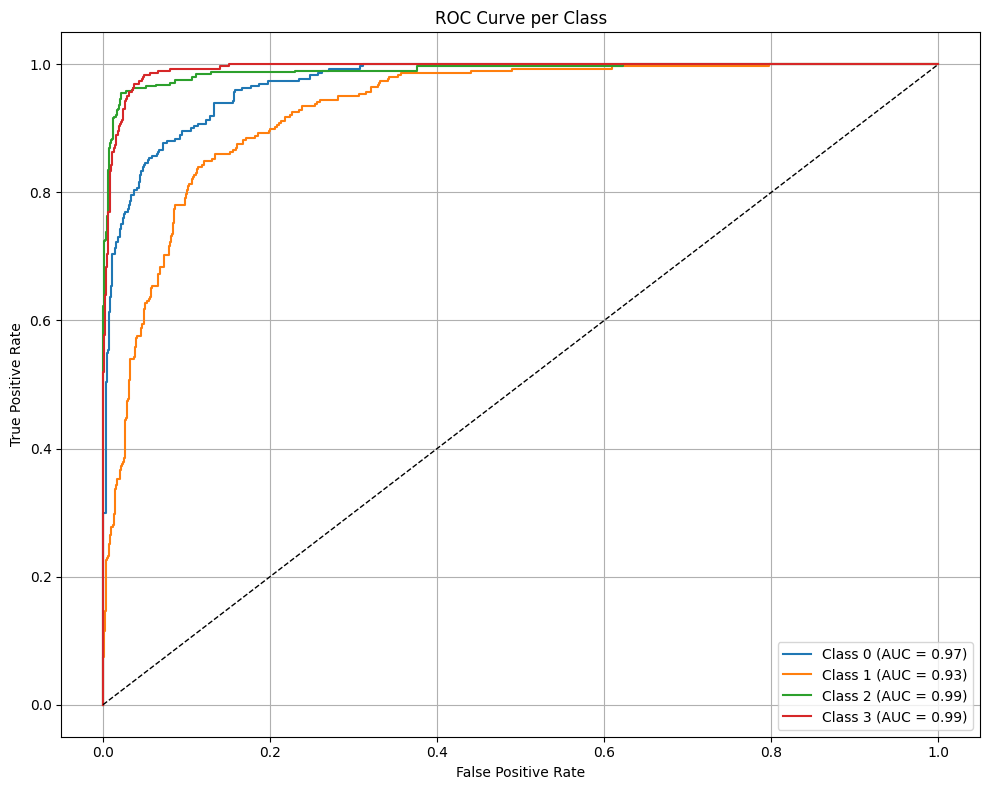

In [85]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Predictions
y_pred = model.predict(test_generator)
y_true = test_generator.classes
n_classes = y_pred.shape[1]

# One-hot encode the true labels
y_true_onehot = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

### Confusion Matrix

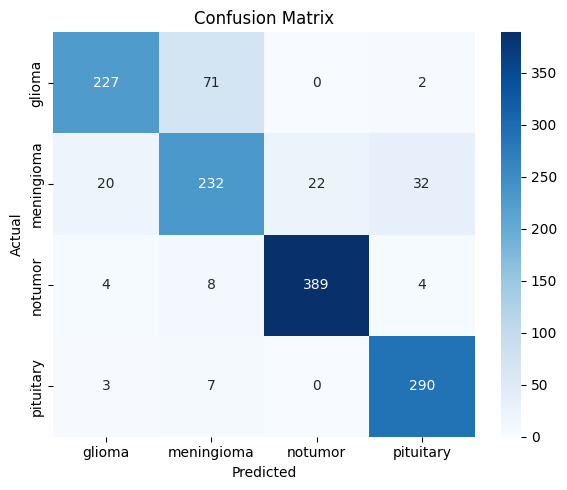

,precision,recall,f1-score,support
glioma,0.894,0.757,0.819,300.000
meningioma,0.730,0.758,0.744,306.000
notumor,0.946,0.960,0.953,405.000
pituitary,0.884,0.967,0.924,300.000
accuracy,0.868,0.868,0.868,0.868
macro avg,0.863,0.860,0.860,1311.000
weighted avg,0.870,0.868,0.867,1311.000


In [86]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd

# Get predicted class indices
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class)
df_cm = pd.DataFrame(cm, index=class_labels, columns=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Classification report (precision, recall, F1)
report = classification_report(y_true_class, y_pred_class, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Round values and print neatly
report_df = report_df.round(3)
display(report_df)

In [88]:
y_true_binarized = label_binarize(y_true_class, classes=np.arange(n_classes))

# Compute macro average metrics
macro_precision = precision_score(y_true_class, y_pred_class, average='macro')
macro_recall = recall_score(y_true_class, y_pred_class, average='macro')
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
macro_auc = roc_auc_score(y_true_binarized, y_pred, average='macro', multi_class='ovr')

# Append MobileNetV2 results
results_df.loc[len(results_df)] = [
    "InceptionResNetV2", 
    test_acc, 
    test_loss, 
    round(macro_precision, 4), 
    round(macro_recall, 4), 
    round(macro_f1, 4), 
    round(macro_auc, 4)
]

# Display the updated results
display(results_df)

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358
2,DenseNet121,0.865751,0.351833,0.8606,0.8585,0.8554,0.9781
3,EfficientNetB0,0.308924,1.378495,0.0772,0.2500,0.1180,0.6661
4,MobileNetV2,0.861937,0.362561,0.8592,0.8540,0.8522,0.9755
5,InceptionV3,0.881007,0.306638,0.8752,0.8743,0.8736,0.9800
6,Xception,0.883295,0.310204,0.8772,0.8778,0.8759,0.9803
7,NASANetMobile,0.834477,0.425686,0.8230,0.8251,0.8186,0.9664
8,InceptionResNetV2,0.868040,0.369368,0.8635,0.8605,0.8600,0.9715


## Resnet101

### Build The Model

In [89]:
from tensorflow.keras.applications import ResNet101
def build_resnet101_model():
    input_tensor = Input(shape=(224, 224, 1))
    rgb_tensor = Lambda(lambda x: tf.image.grayscale_to_rgb(x))(input_tensor)

    base_model = ResNet101(weights='imagenet', include_top=False, input_tensor=rgb_tensor)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model
# Compile the model
model = build_resnet101_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])



171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


### Call Back and Call THe Model

In [90]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("resnet101_brain_tumor.keras", save_best_only=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 75s 358ms/step - accuracy: 0.3400 - loss: 1.5314 - val_accuracy: 0.5329 - val_loss: 1.2316
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 229ms/step - accuracy: 0.4710 - loss: 1.1648 - val_accuracy: 0.5048 - val_loss: 1.1828
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 234ms/step - accuracy: 0.5429 - loss: 1.0749 - val_accuracy: 0.5916 - val_loss: 1.1449
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 235ms/step - accuracy: 0.5622 - loss: 1.0517 - val_accuracy: 0.5706 - val_loss: 1.1180
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 237ms/step - accuracy: 0.5901 - loss: 1.0154 - val_accuracy: 0.6214 - val_loss: 1.0918
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 233ms/step - accuracy: 0.6324 - loss: 0.9791 - val_accuracy: 0.5951 - val_loss: 1.0627
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 233ms/step - accuracy: 0.6487 - loss: 0.9553 - val_accuracy: 0.6310 - val_loss: 1.0402
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 237ms/step - accuracy: 0.6386 - loss: 0

### Accuracy and Loss Of The TEst Dataset

In [91]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step - accuracy: 0.5608 - loss: 1.1176
Test Accuracy: 0.6621
Test Loss: 0.9177


### Test Train and Val Accuracy

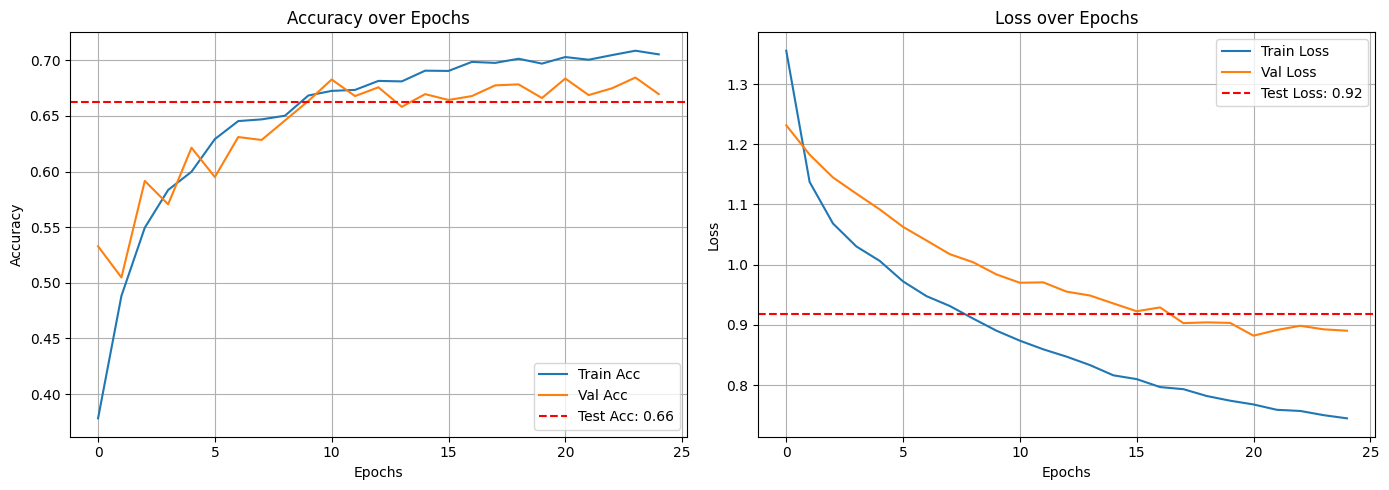

In [92]:
def plot_all_curves(history, test_acc, test_loss):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_all_curves(history, test_acc, test_loss)

### AUC - ROC Curve

41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 325ms/step


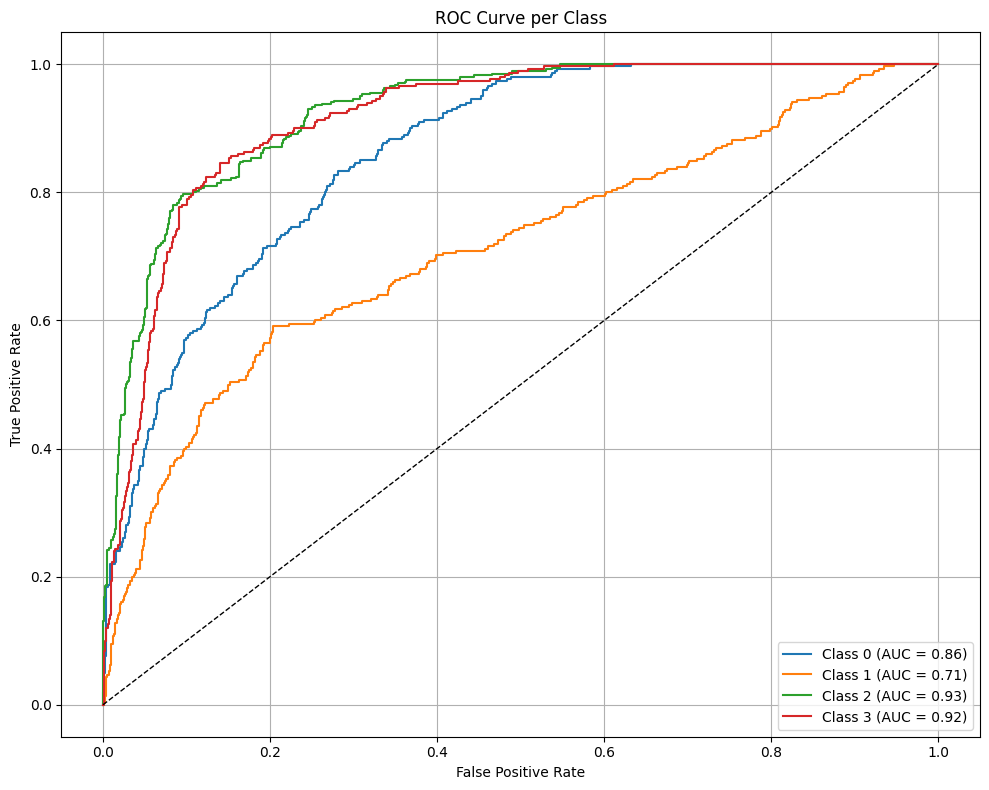

In [93]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Predictions
y_pred = model.predict(test_generator)
y_true = test_generator.classes
n_classes = y_pred.shape[1]

# One-hot encode the true labels
y_true_onehot = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

### Confusion Matrix

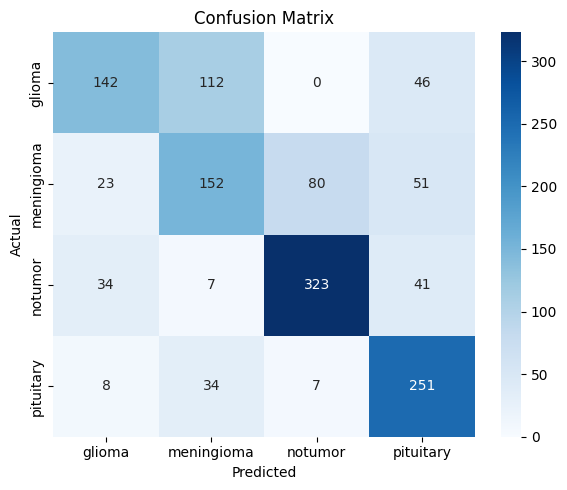

,precision,recall,f1-score,support
glioma,0.686,0.473,0.560,300.000
meningioma,0.498,0.497,0.498,306.000
notumor,0.788,0.798,0.793,405.000
pituitary,0.645,0.837,0.729,300.000
accuracy,0.662,0.662,0.662,0.662
macro avg,0.654,0.651,0.645,1311.000
weighted avg,0.664,0.662,0.656,1311.000


In [94]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd

# Get predicted class indices
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class)
df_cm = pd.DataFrame(cm, index=class_labels, columns=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Classification report (precision, recall, F1)
report = classification_report(y_true_class, y_pred_class, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Round values and print neatly
report_df = report_df.round(3)
display(report_df)

In [96]:
y_true_binarized = label_binarize(y_true_class, classes=np.arange(n_classes))

# Compute macro average metrics
macro_precision = precision_score(y_true_class, y_pred_class, average='macro')
macro_recall = recall_score(y_true_class, y_pred_class, average='macro')
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
macro_auc = roc_auc_score(y_true_binarized, y_pred, average='macro', multi_class='ovr')

# Append MobileNetV2 results
results_df.loc[len(results_df)] = [
    "resnet101", 
    test_acc, 
    test_loss, 
    round(macro_precision, 4), 
    round(macro_recall, 4), 
    round(macro_f1, 4), 
    round(macro_auc, 4)
]

# Display the updated results
display(results_df)

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score,AUC
0,VGG16,0.791762,0.622208,0.7854,0.7815,0.7778,0.9282
1,ResNet50,0.649123,0.968826,0.6300,0.6364,0.6290,0.8358
2,DenseNet121,0.865751,0.351833,0.8606,0.8585,0.8554,0.9781
3,EfficientNetB0,0.308924,1.378495,0.0772,0.2500,0.1180,0.6661
4,MobileNetV2,0.861937,0.362561,0.8592,0.8540,0.8522,0.9755
5,InceptionV3,0.881007,0.306638,0.8752,0.8743,0.8736,0.9800
6,Xception,0.883295,0.310204,0.8772,0.8778,0.8759,0.9803
7,NASANetMobile,0.834477,0.425686,0.8230,0.8251,0.8186,0.9664
8,InceptionResNetV2,0.868040,0.369368,0.8635,0.8605,0.8600,0.9715
9,InceptionResNetV2,0.662090,0.917726,0.6544,0.6511,0.6447,0.8541


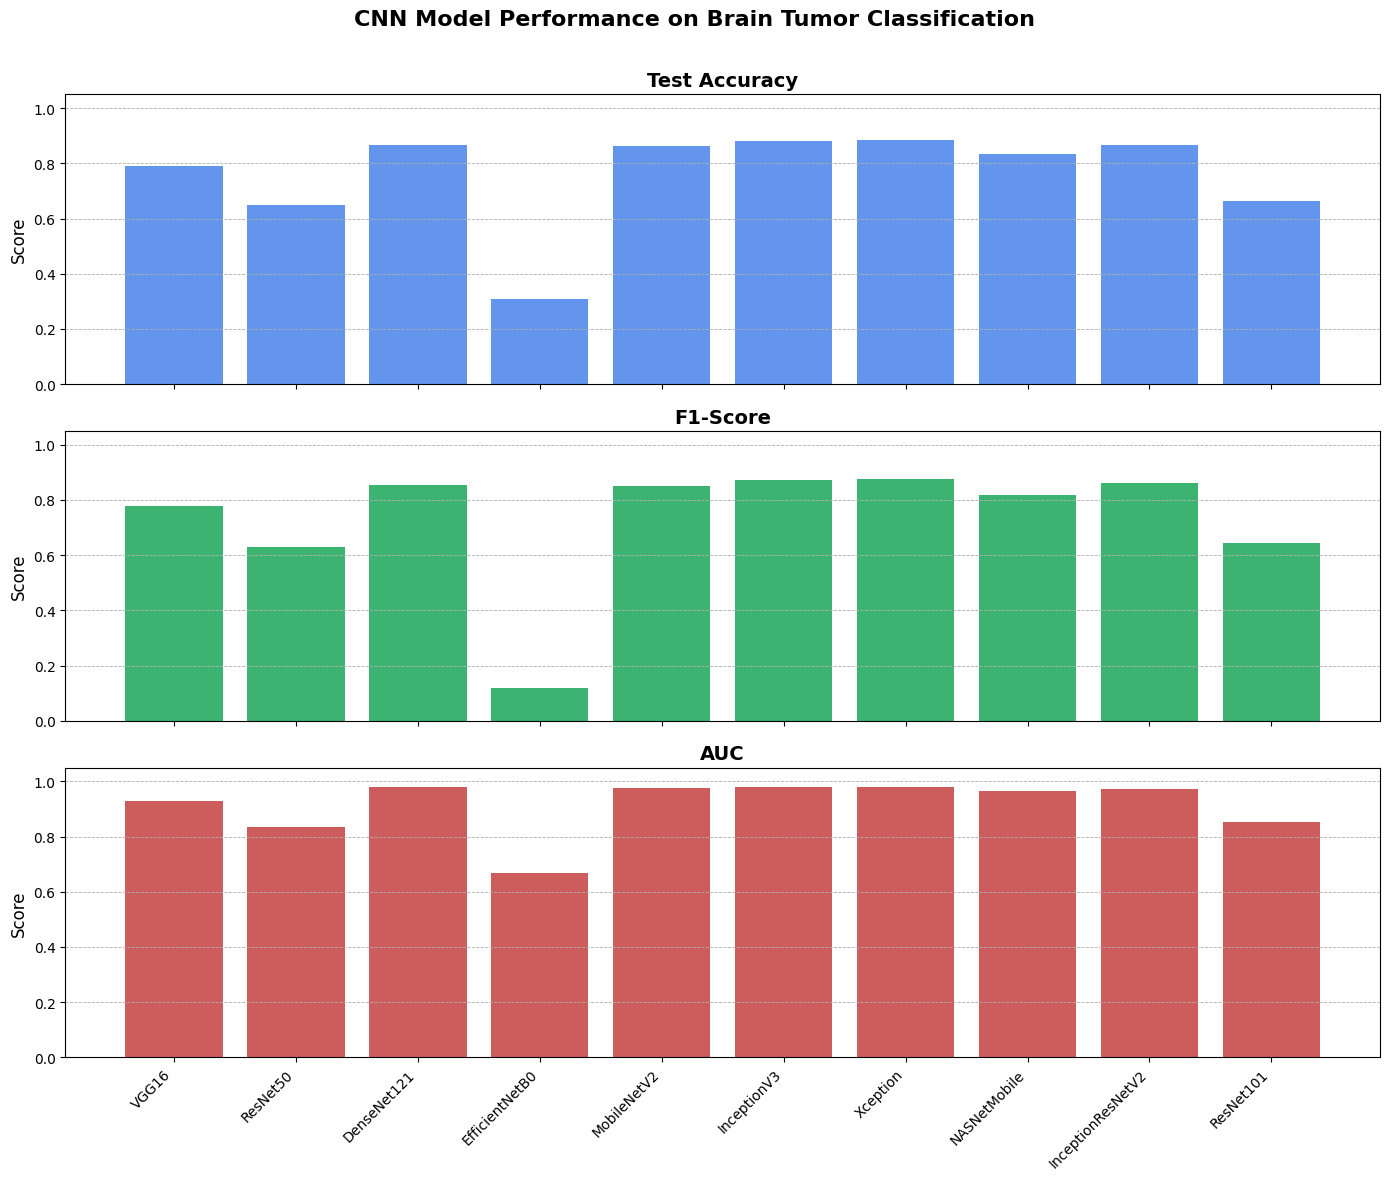

In [97]:

# Create DataFrame
results_df = pd.DataFrame({
    "Model": [
        "VGG16", "ResNet50", "DenseNet121", "EfficientNetB0", "MobileNetV2",
        "InceptionV3", "Xception", "NASNetMobile", "InceptionResNetV2", "ResNet101"
    ],
    "Test Accuracy": [0.791762, 0.649123, 0.865751, 0.308924, 0.861937,
                      0.881007, 0.883295, 0.834477, 0.868040, 0.662090],
    "F1-Score": [0.7778, 0.6290, 0.8554, 0.1180, 0.8522,
                 0.8736, 0.8759, 0.8186, 0.8600, 0.6447],
    "AUC": [0.9282, 0.8358, 0.9781, 0.6661, 0.9755,
            0.9800, 0.9803, 0.9664, 0.9715, 0.8541]
})

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

metrics = ["Test Accuracy", "F1-Score", "AUC"]
colors = ["cornflowerblue", "mediumseagreen", "indianred"]

for i, metric in enumerate(metrics):
    axes[i].bar(results_df["Model"], results_df[metric], color=colors[i])
    axes[i].set_title(metric, fontsize=14, weight='bold')
    axes[i].set_ylabel("Score", fontsize=12)
    axes[i].set_ylim(0, 1.05)
    axes[i].grid(True, axis='y', linestyle='--', linewidth=0.6)

plt.xticks(rotation=45, ha='right')
plt.suptitle("CNN Model Performance on Brain Tumor Classification", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save the plot
plt.savefig("cnn_model_comparison.png", dpi=300)
plt.show()